# Проект Рекомендательные системы

## Описание проекта
Необходимо разработать рекомендательную систему для e-commerce платформы на основе исторических данных о поведении пользователей. 

**Цель проекта** — создать персонализированную систему рекомендаций товаров, которая поможет повысить конверсию и увеличить продажи. Система должна предсказывать, какие товары с наибольшей вероятностью купит конкретный пользователь, и предоставлять топ-3 рекомендации. После проведения разведывательного анализа данных и feature engineering была создана серия моделей машинного обучения различных типов и проведено их сравнение.

## Этапы работы над проектом:
#### 1. Постановка задачи и выбор метрики качества
#### 2. Первичный анализ и описание данных
#### 3. Разведывательный анализ данных (EDA)
#### 4. Предобработка и очистка данных
#### 5. Валидация: временное разбиение данных
#### 6. Генерация признаков (Feature Engineering)
* **Факторы товаров** (иерархические, ценовые, конверсионные)
* **Факторы взаимодействий** пользователь-товар
* **Создание матриц взаимодействий**
#### 7. Корреляционный анализ и оптимизация признаков
#### 8. Построение рекомендательных моделей:
* **NMF** (Неотрицательная матричная факторизация)
* **LightFM** (Гибридная модель)
#### 9. Подбор гиперпараметров и валидация
#### 10. Оценка качества на тестовой выборке
#### 11. Сравнительный анализ моделей

## Основные характеристики данных:
**Объем данных:** 2,756,101 событий пользователей за период май-сентябрь 2015

**Пользователи:** 1,407,580 уникальных посетителей

**Товары:** 235,061 уникальных товаров

**Категории:** 1,669 категорий товаров с иерархической структурой

**Свойства товаров:** 1,104 уникальных признака товаров

**Целевая метрика:** Precision@3 (точность для топ-3 рекомендаций)

**Baseline:** 0.61% (рекомендация популярных товаров)

### Признаки в данных:
#### События пользователей (events.csv):
* timestamp - временная метка события
* visitorid - идентификатор пользователя
* event - тип события (view, addtocart, transaction)
* itemid - идентификатор товара
* transactionid - идентификатор транзакции

**Структура событий:**
* **view** (96.7%) - просмотры товаров
* **addtocart** (2.5%) - добавления в корзину
* **transaction** (0.8%) - покупки

#### Иерархия категорий (category_tree.csv):
* **categoryid** - идентификатор категории
* **parentid** - идентификатор родительской категории

#### Свойства товаров (item_properties_part1.csv, item_properties_part2.csv):
* **timestamp** - временная метка изменения свойства
* **itemid** - идентификатор товара
* **property** - название свойства (categoryid, цена, доступность и др.)
* **value** - значение свойства

#### Особенности данных:
* **Крайняя разреженность:** плотность матрицы взаимодействий ~0.01%
* **Временная структура:** данные имеют четкую временную последовательность
* **Дисбаланс классов:** только 0.8% событий являются транзакциями
* **Проблема холодного старта:** много товаров и пользователей с минимальной активностью

## 1. Импорт необходимых библиотек

In [1]:
# Установка необходимых библиотек
!pip install lightfm
!pip install causalml catboost xgboost

import pickle
import random
import time
import warnings
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
# Базовые библиотеки
import pandas as pd
import seaborn as sns
# XGBoost
# LightFM
from lightfm import LightFM
from lightfm.data import Dataset as LightFMDataset
from scipy import sparse, stats
# Scipy
from scipy.sparse import csr_matrix, load_npz, save_npz
# Sklearn
from sklearn.decomposition import NMF
# Утилиты
from tqdm import tqdm

warnings.filterwarnings("ignore")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.4/316.4 kB 5.3 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
  Created wheel for lightfm: filename=lightfm-1.17-cp311-cp311-linux_x86_64.whl size=831128 sha256=eeba37d02edcca6d990207ffc8e46690ba603b948eebdf40d513250729006104
  Stored in directory: /root/.cache/pip/wheels/b9/0d/8a/0729d2e6e3ca2a898ba55201f905da7db3f838a33df5b3fcdd
Successfully built lightfm
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 53.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 81.9 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: pathos
    Found existing installation: pathos 0.3.1
    Uninstalling pathos-0.3.1:
      Successfully uninstalled pathos-0.3.1
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-le

In [2]:
!pip install gdown


import gdown

# ID папки на Google Диске
folder_id = "1n4yV2pFRLA1OLTQmNsIBHqWDmKISkRtq"
url = f"https://drive.google.com/drive/folders/{folder_id}"

# Скачивание папки
gdown.download_folder(url, output="./", quiet=False)

Retrieving folder contents


Processing file 1bTe5_C19YVgQ8UCsXUs6nnZ68nET4vil category_tree.csv
Processing file 1si7siK48VsTGBBAdiXi1CXJQJMNdiCnA events.csv
Processing file 1pymGw3Pe0ZcDbge9_SVyy9VpJy06d4i8 item_properties_part1.csv
Processing file 12OoEkG8rQl58SCOz3QLMqO17asugsMmH item_properties_part2.csv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1bTe5_C19YVgQ8UCsXUs6nnZ68nET4vil
To: /kaggle/working/files/category_tree.csv
100%|██████████| 14.5k/14.5k [00:00<00:00, 14.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1si7siK48VsTGBBAdiXi1CXJQJMNdiCnA
To: /kaggle/working/files/events.csv
100%|██████████| 94.2M/94.2M [00:00<00:00, 175MB/s] 
Downloading...
From (original): https://drive.google.com/uc?id=1pymGw3Pe0ZcDbge9_SVyy9VpJy06d4i8
From (redirected): https://drive.google.com/uc?id=1pymGw3Pe0ZcDbge9_SVyy9VpJy06d4i8&confirm=t&uuid=9e44f4ff-aa34-4b46-98b4-afa7fd52ceb5
To: /kaggle/working/files/item_properties_part1.csv
100%|██████████| 484M/484M [00:03<00:00, 131MB/s]  
Downloading...
From (original): https://drive.google.com/uc?id=12OoEkG8rQl58SCOz3QLMqO17asugsMmH
From (redirected): https://drive.google.com/uc?id=12OoEkG8rQl58SCOz3QLMqO17asugsMmH&confirm=t&uuid=c0e

['./files/category_tree.csv',
 './files/events.csv',
 './files/item_properties_part1.csv',
 './files/item_properties_part2.csv']

## 2. Чтение файлов данных

In [3]:
# Читаем файл с событиями
events = pd.read_csv("files/events.csv")

# Читаем файл с деревом категорий
category_tree = pd.read_csv("files/category_tree.csv")

# Читаем файлы со свойствами товаров (две части)
item_properties_part1 = pd.read_csv("files/item_properties_part1.csv")
item_properties_part2 = pd.read_csv("files/item_properties_part2.csv")

## 3. Проверка структуры данных
### 3.1 Вывод первых строк всех датасетов

In [4]:
print("Первые 5 строк events:")
display(events.head())
print("\nПервые 5 строк category_tree:")
display(category_tree.head())
print("\nПервые 5 строк item_properties_part1:")
display(item_properties_part1.head())
print("\nПервые 5 строк item_properties_part2:")
display(item_properties_part2.head())

Первые 5 строк events:


,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN



Первые 5 строк category_tree:


,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0



Первые 5 строк item_properties_part1:


,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513



Первые 5 строк item_properties_part2:


,timestamp,itemid,property,value
0,1433041200000,183478,561,769062
1,1439694000000,132256,976,n26.400 1135780
2,1435460400000,420307,921,1149317 1257525
3,1431831600000,403324,917,1204143
4,1435460400000,230701,521,769062


### 3.2 Общая информация о структуре данных
Анализируем основные характеристики всех загруженных таблиц: типы данных, пропуски, размерность.

In [5]:
# Анализируем структуру основных таблиц
print("EVENTS")
events.info()
print("\nCATEGORY_TREE")
category_tree.info()
print("\nITEM_PROPERTIES_PART1")
item_properties_part1.info()
print("\nITEM_PROPERTIES_PART2")
item_properties_part2.info()

EVENTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          object 
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 105.1+ MB

CATEGORY_TREE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1669 entries, 0 to 1668
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   categoryid  1669 non-null   int64  
 1   parentid    1644 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 26.2 KB

ITEM_PROPERTIES_PART1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999999 entries, 0 to 10999998
Data columns (total 4 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   timestamp  int64 
 1   itemid     int64 
 2   property   object
 3   value      object
dtypes: in

### 3.3 Описательная статистика
Получаем статистические характеристики числовых полей для выявления аномалий и понимания распределений.

In [6]:
print("Описательная статистика events:")
display(events.describe())

print("\nОписательная статистика category_tree:")
display(category_tree.describe())

print("\nОписательная статистика item_properties_part1:")
display(item_properties_part1.describe())

print("\nОписательная статистика item_properties_part2:")
display(item_properties_part2.describe())

Описательная статистика events:


,timestamp,visitorid,itemid,transactionid
count,2.756101e+06,2.756101e+06,2.756101e+06,22457.000000
mean,1.436424e+12,7.019229e+05,2.349225e+05,8826.497796
std,3.366312e+09,4.056875e+05,1.341954e+05,5098.996290
min,1.430622e+12,0.000000e+00,3.000000e+00,0.000000
25%,1.433478e+12,3.505660e+05,1.181200e+05,4411.000000
50%,1.436453e+12,7.020600e+05,2.360670e+05,8813.000000
75%,1.439225e+12,1.053437e+06,3.507150e+05,13224.000000
max,1.442545e+12,1.407579e+06,4.668670e+05,17671.000000



Описательная статистика category_tree:


,categoryid,parentid
count,1669.000000,1644.000000
mean,849.285201,847.571168
std,490.195116,505.058485
min,0.000000,8.000000
25%,427.000000,381.000000
50%,848.000000,866.000000
75%,1273.000000,1291.000000
max,1698.000000,1698.000000



Описательная статистика item_properties_part1:


,timestamp,itemid
count,1.100000e+07,1.100000e+07
mean,1.435158e+12,2.333851e+05
std,3.327653e+09,1.348258e+05
min,1.431227e+12,0.000000e+00
25%,1.432436e+12,1.165150e+05
50%,1.433646e+12,2.334990e+05
75%,1.437880e+12,3.501860e+05
max,1.442113e+12,4.668660e+05



Описательная статистика item_properties_part2:


,timestamp,itemid
count,9.275903e+06,9.275903e+06
mean,1.435156e+12,2.333968e+05
std,3.327970e+09,1.348682e+05
min,1.431227e+12,0.000000e+00
25%,1.432436e+12,1.165175e+05
50%,1.433646e+12,2.334620e+05
75%,1.437880e+12,3.504470e+05
max,1.442113e+12,4.668660e+05


#### Выводы по структуре данных
#### Объем и структура:
* **Events:** 2.7M записей за период май-сентябрь 2015
* **Category_tree:** 1,669 категорий с корректной иерархией (25 корневых + 1,644 подкатегории)
* **Item_properties:** 20.3M записей свойств товаров (разделены на 2 файла)

#### Качество данных:
* **Критические пропуски:** transactionid отсутствует в 99% записей events (только 22,457 транзакций), что подтверждает низкую конверсию типичную для e-commerce
* **Структурные пропуски:** 25 записей без parentid в category_tree соответствуют корневым категориям
* **Нулевые ID:** обнаружены в visitorid (events) и itemid (обе таблицы) - требуют проверки на валидность
* Временные диапазоны согласованы между таблицами

#### Выявленные проблемы совместимости:
* **Типы данных категорий:** int64 в category_tree vs object в item_properties потребует конвертации для объединения
* **Неоднородность value:** столбец содержит числа, строки и списки, что усложнит генерацию признаков
* **Воронка событий:** критический дисбаланс view >> addtocart >> transaction потребует специальной обработки

#### Особенности для моделирования:
* Разреженность транзакций (0.8% от всех событий) потребует weighted подходов
* 1,100+ свойств товаров потребуют селекции признаков  
* Широкие диапазоны ID (0-1.4M пользователей, 0-467K товаров) указывают на масштабность данных

Данные готовы для EDA **после обработки пропусков, конвертации типов и проверки нулевых ID**.

#### Задание 2.1

Сколько записей событий находится в датасете? Ответ введите без пробелов и знаков препинания.

In [7]:
events_count = len(events)
print(f"Количество записей событий: {events_count}")

Количество записей событий: 2756101


#### Задание 2.2

Какие типы событий содержатся в датасете?

In [8]:
unique_events = events["event"].unique()
print(f"Уникальные типы событий: {unique_events}")

Уникальные типы событий: ['view' 'addtocart' 'transaction']


#### Задание 2.3

Сколько уникальных признаков товара есть в датасете?

In [9]:
# Объединяем две части свойств товаров и подсчитываем уникальные признаки
item_properties = pd.concat(
    [item_properties_part1, item_properties_part2], ignore_index=True
)
unique_properties = item_properties["property"].nunique()
print(f"Количество уникальных признаков товара: {unique_properties}")

Количество уникальных признаков товара: 1104


#### Задание 2.4

Анастасия: Кстати, слушай… Это, конечно, не моё дело, но мы же не можем оптимизировать оборот? Как думаешь, как мы будем измерять качество рекомендаций? У нас вроде только три места для показа товаров на главной странице. А ведь клиента интересует только продажи!

**Precision@3** - оптимальная метрика по трем ключевым причинам:

**Соответствие интерфейсу**
У нас ровно 3 слота для рекомендаций, поэтому Precision@3 измеряет эффективность именно в этих рамках.

**Фокус на продажах**
Метрика показывает долю рекомендованных товаров, которые пользователь реально купил - прямая связь с оборотом компании.

**Простота для бизнеса**
Легко интерпретировать: "Из 3 рекомендаций пользователь купил 2" = 66.7%. Понятно руководству и удобно для A/B тестов.

**Вывод:** Precision@3 идеально балансирует бизнес-цели, технические ограничения и пользовательское поведение.

#### Задание 4.1

Какой процент продаж обеспечивают топовые товары (точка отсечения — 1 июля включительно)? Для расчёта используйте топ-3 товаров по числу транзакций.

In [10]:
# Преобразуем timestamp в datetime
events["datetime"] = pd.to_datetime(events["timestamp"], unit="ms")

# Определяем точку отсечения - начало 2 июля 2015 года
cutoff_date = pd.to_datetime("2015-07-02")

# Разделяем данные по точке отсечения
events_before = events[events["datetime"] <= cutoff_date]
events_after = events[events["datetime"] > cutoff_date]

# Фильтруем только транзакции до точки отсечения
transactions_before = events_before[events_before["event"] == "transaction"]

# Подсчитываем топ-3 товара по кол-ву транзакций до точки отсечения
top_3_items = transactions_before["itemid"].value_counts().head(3)
print("Топ-3 товара по транзакциям до 1 июля включительно:")
print(top_3_items)

# Получаем список ID топ-3 товаров
top_3_item_ids = top_3_items.index.tolist()

# Фильтруем транзакции после точки отсечения
transactions_after = events_after[events_after["event"] == "transaction"]

# Подсчитываем транзакции топ-3 товаров после точки отсечения
top_3_sales_after = transactions_after[
    transactions_after["itemid"].isin(top_3_item_ids)
]

# Рассчитываем процент покрытия
total_sales_after = len(transactions_after)
top_3_sales_count = len(top_3_sales_after)
coverage_percentage = (top_3_sales_count / total_sales_after) * 100

print("\nСтатистика после 1 июля:")
print(f"Общее количество транзакций: {total_sales_after}")
print(f"Транзакции топ-3 товаров: {top_3_sales_count}")
print(f"Процент продаж топовых товаров: {coverage_percentage:.2f}")

Топ-3 товара по транзакциям до 1 июля включительно:
itemid
119736    36
369447    31
7943      30
Name: count, dtype: int64

Статистика после 1 июля:
Общее количество транзакций: 12608
Транзакции топ-3 товаров: 77
Процент продаж топовых товаров: 0.61


0.61% означает: если бы мы всем пользователям рекомендовали эти 3 самых популярных товара, мы бы "поймали" только 0.61% от всех покупок после 1 июля.

Вывод: Простая стратегия "топ товары для всех" крайне неэффективна, нужны персонализированные рекомендации!

## 4. Разведывательный анализ данных (EDA)

### 4.1 Анализ Baseline: Эффективность популярных товаров

Результат 0.61% покрытия продаж топ-3 товаров (из задания 4.1) служит baseline. Это показывает низкую эффективность стратегии "топ товары всем" и обосновывает необходимость персонализации. Используется как эталон для сравнения с будущими моделями.

### 4.2 Обзор структуры данных

#### 4.2.1 Основные характеристики датасета
Анализируем ключевые метрики: распределение типов событий, масштаб пользовательской базы и товарного каталога, временные рамки данных.

In [11]:
event_distribution = events["event"].value_counts(normalize=True) * 100
print("Статистика по событиям:")
print(event_distribution)
print("\nУникальные пользователи:", events["visitorid"].nunique())
print("Уникальные товары:", events["itemid"].nunique())
print("Диапазон дат:", events["datetime"].min(), "до", events["datetime"].max())

Статистика по событиям:
event
view           96.669607
addtocart       2.515583
transaction     0.814810
Name: proportion, dtype: float64

Уникальные пользователи: 1407580
Уникальные товары: 235061
Диапазон дат: 2015-05-03 03:00:04.384000 до 2015-09-18 02:59:47.788000


### 4.2.2 Проверка нулевых идентификаторов
Анализируем наличие некорректных нулевых значений в ключевых полях **visitorid** и **itemid**, которые могут указывать на проблемы сбора данных.

In [12]:
# Анализ нулевых идентификаторов
zero_visitors = events[events["visitorid"] == 0]
zero_items = events[events["itemid"] == 0]

print(f"Записей с visitorid = 0: {len(zero_visitors)}")
print(f"Записей с itemid = 0: {len(zero_items)}")

Записей с visitorid = 0: 3
Записей с itemid = 0: 0


#### 4.2.3 Проверка дубликатов записей
Выявляем полностью идентичные записи, которые могут исказить статистики взаимодействий и повлиять на качество рекомендаций.

In [13]:
duplicates = events.duplicated().sum()
print(f"Полных дубликатов записей: {duplicates}")

Полных дубликатов записей: 460


#### 4.2.4 Анализ пропусков в transactionid
Проверяем корректность заполнения transactionid - поле должно быть пустым для событий view/addtocart и заполненным только для transaction.

In [14]:
print("Пропуски transactionid по типам событий:")

# View события
view_events = events[events["event"] == "view"]
view_missing = view_events["transactionid"].isnull().sum()
view_total = len(view_events)
print(f"  view: {view_missing} из {view_total}")

# AddToCart события
addtocart_events = events[events["event"] == "addtocart"]
addtocart_missing = addtocart_events["transactionid"].isnull().sum()
addtocart_total = len(addtocart_events)
print(f"  addtocart: {addtocart_missing} из {addtocart_total}")

# Transaction события
transaction_events = events[events["event"] == "transaction"]
transaction_missing = transaction_events["transactionid"].isnull().sum()
transaction_total = len(transaction_events)
print(f"  transaction: {transaction_missing} из {transaction_total}")

Пропуски transactionid по типам событий:
  view: 2664312 из 2664312
  addtocart: 69332 из 69332
  transaction: 0 из 22457


#### Выводы
Структура пользовательского поведения показывает классическую воронку продаж: большинство взаимодействий (96.7%) составляют просмотры товаров, значительно меньше добавлений в корзину (2.5%) и лишь 0.8% завершаются покупкой. Масштаб данных впечатляющий: 1.4 миллиона пользователей взаимодействовали с 235 тысячами товаров за 4.5 месяца, что создает разреженную матрицу взаимодействий - типичный вызов для рекомендательных систем.

Качество данных высокое: выявлены лишь 3 записи с нулевыми **visitorid** и 460 дубликатов, что не критично для моделирования. Структура **transactionid** корректна - поле заполнено только для покупок, как и ожидается.

Низкий **conversion rate** в 0.8% подтверждает сложность задачи персонализации и объясняет слабый результат baseline-стратегии (0.61% покрытия), демонстрируя критическую необходимость в умных алгоритмах рекомендаций.

### 4.3 Анализ совместимости систем данных

#### 4.3.1 Объединяем данные о свойствах товаров для анализа

In [15]:
item_properties = pd.concat(
    [item_properties_part1, item_properties_part2], ignore_index=True
)

Данные объединены, готовы к анализу совместимости категорий.

#### 4.3.2 Анализ типов данных

In [16]:
# Анализ типов данных категорий
print("Типы данных categoryid в разных источниках:")

# В item_properties
item_categories_sample = item_properties[item_properties["property"] == "categoryid"][
    "value"
].head(10)
print(f"item_properties categories (sample): {list(item_categories_sample)}")
print(f"item_properties categories type: {type(item_categories_sample.iloc[0])}")

# В category_tree
tree_categories_sample = category_tree["categoryid"].head(10)
print(f"category_tree categories (sample): {list(tree_categories_sample)}")
print(f"category_tree categories type: {type(tree_categories_sample.iloc[0])}")

Типы данных categoryid в разных источниках:
item_properties categories (sample): ['1338', '1277', '1059', '1147', '47', '619', '1228', '1277', '546', '1226']
item_properties categories type: <class 'str'>
category_tree categories (sample): [1016, 809, 570, 1691, 536, 231, 542, 1146, 1140, 1479]
category_tree categories type: <class 'numpy.int64'>


Обнаружено критическое различие в типах данных: категории товаров хранятся как строки, категории дерева - как числа. Это объясняет потенциальные проблемы совместимости.

#### 4.3.3 Проверка совместимости

In [17]:
# Проверим пересечение категорий до конвертации
item_cats_original = set(
    item_properties[item_properties["property"] == "categoryid"]["value"].unique()
)
tree_cats = set(category_tree["categoryid"].unique())
intersection_before = len(item_cats_original & tree_cats)

print(f"Уникальных категорий товаров: {len(item_cats_original)}")
print(f"Категорий в дереве: {len(tree_cats)}")
print(f"Пересечение (до конвертации): {intersection_before}")

# Попробуем конвертировать строки в числа и проверим снова
item_cats_converted = set(
    pd.to_numeric(
        item_properties[item_properties["property"] == "categoryid"]["value"],
        errors="coerce",
    )
    .dropna()
    .astype(int)
)

intersection_after = len(item_cats_converted & tree_cats)
print(f"Пересечение (после конвертации): {intersection_after}")

Уникальных категорий товаров: 1242
Категорий в дереве: 1669
Пересечение (до конвертации): 0
Пересечение (после конвертации): 1212


Проблема: категории товаров записаны как текст ('1338'), а в дереве категорий - как числа (1338). Простое преобразование текста в числа полностью решает проблему и открывает доступ к 1212 категориям для иерархических признаков.

### 4.4 Визуализация данных

Для лучшего понимания структуры данных построим три ключевых графика: распределение типов событий для анализа воронки продаж, активность пользователей по дням недели для выявления временных паттернов, и топ-10 самых покупаемых товаров для оценки концентрации продаж.

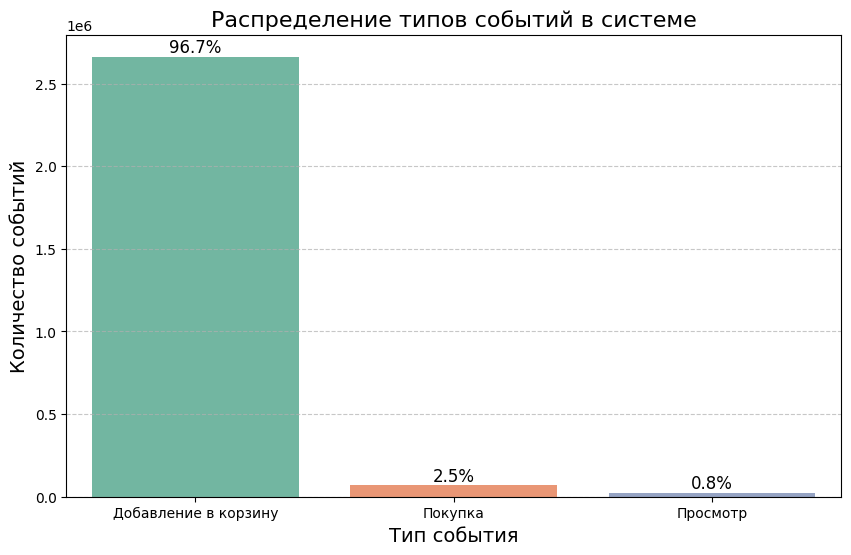

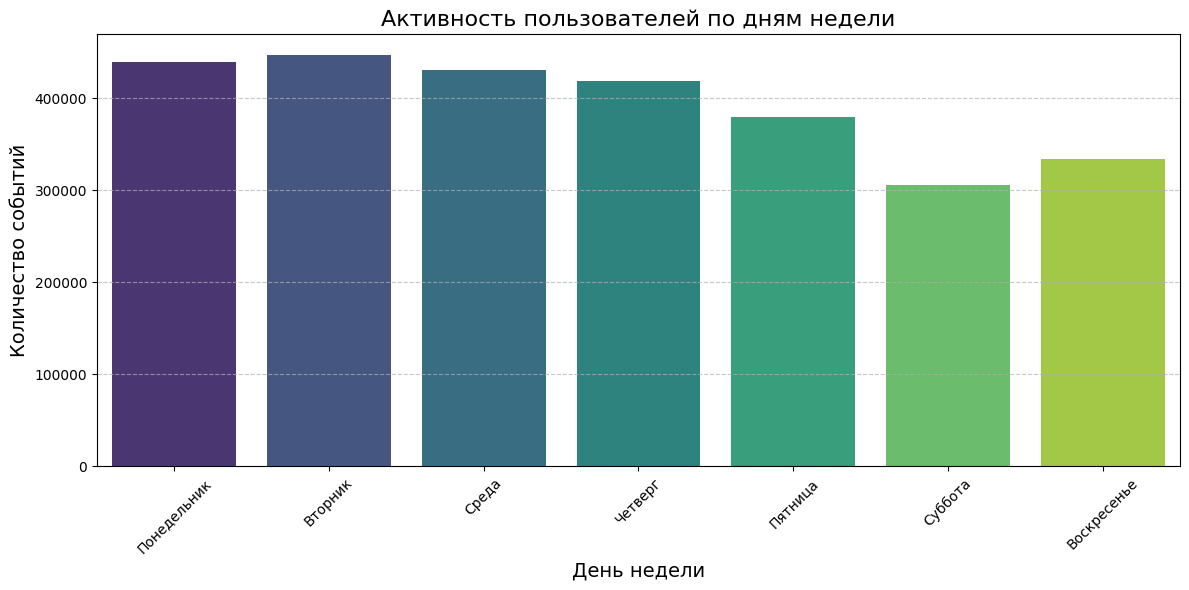

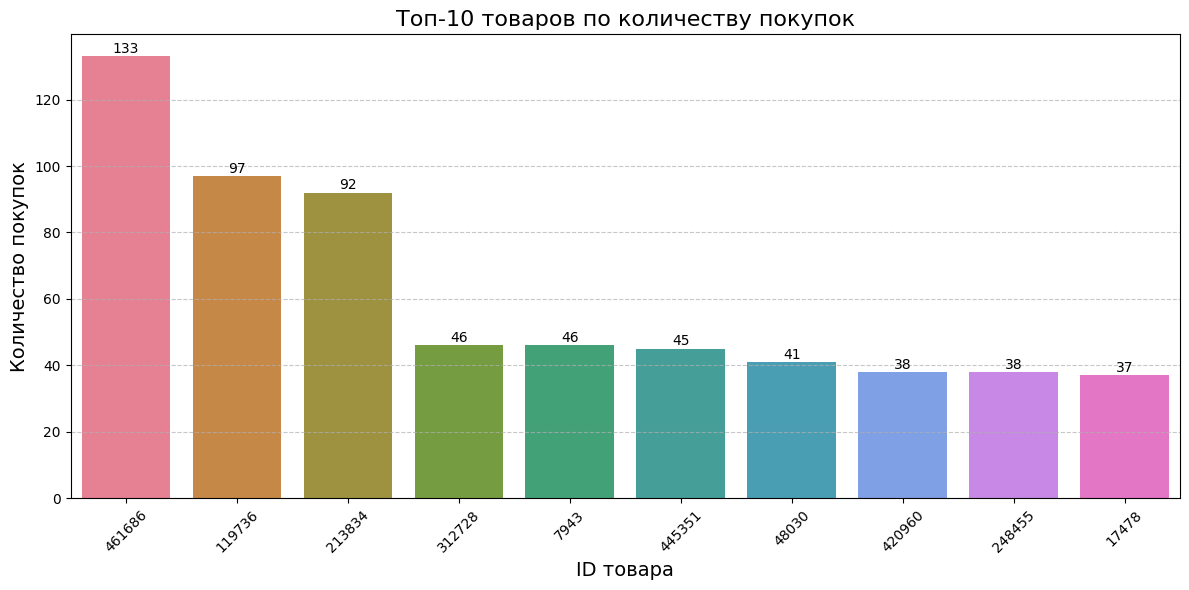

In [18]:
# График 1: Распределение типов событий
fig = plt.figure(figsize=(10, 6))
ax = sns.countplot(data=events, x="event", palette="Set2")

# Настройка заголовков и подписей
ax.set_title("Распределение типов событий в системе", fontsize=16)
ax.set_xlabel("Тип события", fontsize=14)
ax.set_ylabel("Количество событий", fontsize=14)

# Подписи на оси X
ax.set_xticklabels(["Добавление в корзину", "Покупка", "Просмотр"])

# Добавление сетки для улучшения читаемости
ax.grid(axis="y", linestyle="--", alpha=0.7)

# Добавляем проценты на столбцы
total = len(events)
for p in ax.patches:
    percentage = "{:.1f}%".format(100 * p.get_height() / total)
    ax.annotate(
        percentage,
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=12,
    )

plt.show()

# График 2: Активность по дням недели
temp_data = events.copy()
temp_data["day_of_week"] = temp_data["datetime"].dt.dayofweek

fig = plt.figure(figsize=(12, 6))
ax = sns.countplot(data=temp_data, x="day_of_week", palette="viridis")

# Настройка заголовков и подписей
ax.set_title("Активность пользователей по дням недели", fontsize=16)
ax.set_xlabel("День недели", fontsize=14)
ax.set_ylabel("Количество событий", fontsize=14)

# Названия дней
days = [
    "Понедельник",
    "Вторник",
    "Среда",
    "Четверг",
    "Пятница",
    "Суббота",
    "Воскресенье",
]
ax.set_xticklabels(days, rotation=45)

# Добавление сетки
ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

# График 3: Топ-10 товаров по покупкам
top_items = events[events["event"] == "transaction"]["itemid"].value_counts().head(10)

fig = plt.figure(figsize=(12, 6))
ax = sns.barplot(x=top_items.index.astype(str), y=top_items.values, palette="husl")

# Настройка заголовков и подписей
ax.set_title("Топ-10 товаров по количеству покупок", fontsize=16)
ax.set_xlabel("ID товара", fontsize=14)
ax.set_ylabel("Количество покупок", fontsize=14)

# Поворачиваем подписи на оси X
plt.xticks(rotation=45)

# Добавление сетки
ax.grid(axis="y", linestyle="--", alpha=0.7)

# Добавляем значения на столбцы
for i, v in enumerate(top_items.values):
    ax.text(i, v + 0.1, str(v), ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

#### Выводы по визуализации
Воронка продаж демонстрирует типичную структуру e-commerce: 96.7% просмотров при всего 0.8% транзакций. Активность по дням недели распределена равномерно без выраженной сезонности. Топ-товары показывают крайне низкую концентрацию - даже лидер (ID 461686) набирает лишь ~70 покупок из 12,608 транзакций.

Структура данных объясняет провал baseline-стратегии (0.61% покрытия): при огромном каталоге (235K товаров) покупки максимально рассеяны, что делает персонализацию критически необходимой для эффективных рекомендаций.

### 4.5 Анализ выбросов и аномалий поведения
Исследуем распределения ключевых метрик с помощью боксплотов для выявления аномальной активности пользователей, популярности товаров и временных паттернов системы.

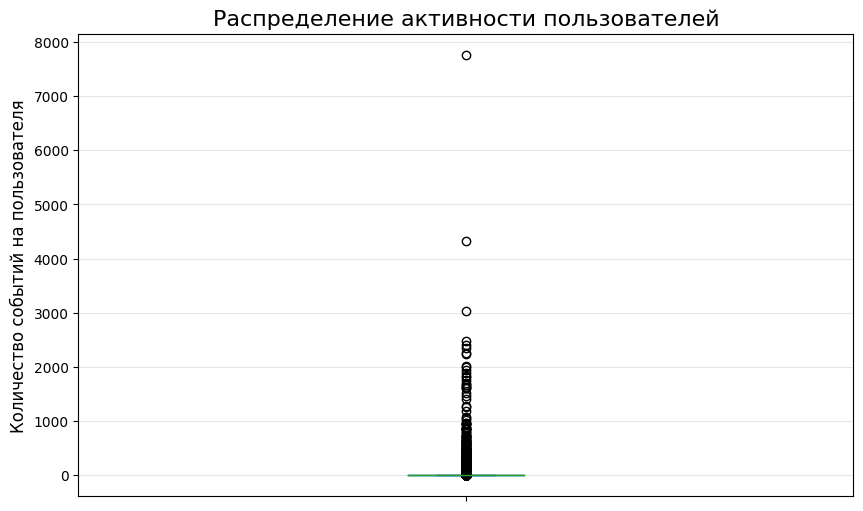

In [19]:
# 1. Активность пользователей
user_activity = events.groupby("visitorid").size()
plt.figure(figsize=(10, 6))
user_activity.plot.box()
plt.title("Распределение активности пользователей", fontsize=16)
plt.ylabel("Количество событий на пользователя", fontsize=12)
plt.grid(axis="y", alpha=0.3)
plt.show()

**Выводы:**
* Медиана ~1-2 события - большинство пользователей пассивны
* Множество выбросов до ~2500 событий - супер-активные пользователи
* Длинный правый "хвост" - типично для пользовательской активности

**По выбросам: не удаляем!** Это ценные данные:
* Супер-активные пользователи = лучшие клиенты
* Для рекомендательных систем активность = больше сигнала
* Возможные корпоративные аккаунты или лояльные покупатели

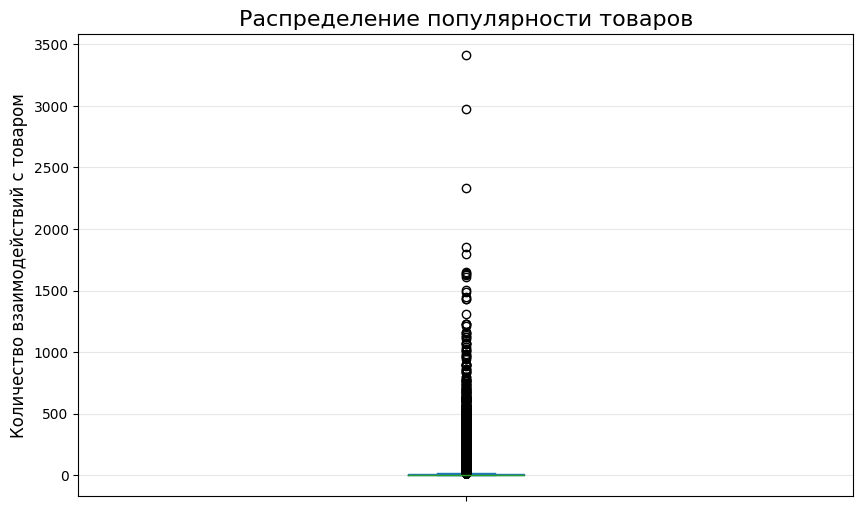

In [20]:
# 2. Популярность товаров
item_popularity = events.groupby("itemid").size()
plt.figure(figsize=(10, 6))
item_popularity.plot.box()
plt.title("Распределение популярности товаров", fontsize=16)
plt.ylabel("Количество взаимодействий с товаром", fontsize=12)
plt.grid(axis="y", alpha=0.3)
plt.show()

**Выводы:**
* Медиана ~1-5 взаимодействий - большинство товаров малопопулярны
* Выбросы до ~3400 взаимодействий - хиты/бестселлеры
* Принцип 80/20 - типично для e-commerce

**По выбросам: не удаляем!** Критически важны:
* Популярные товары = основа для рекомендаций
* "Длинный хвост" + хиты = полная картина каталога
* Популярность товара - ключевой признак для ML

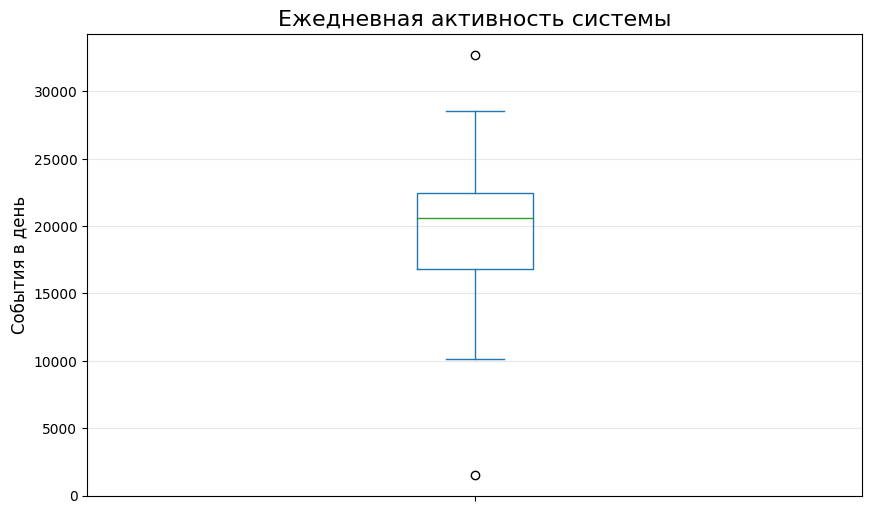

In [21]:
# 3. Ежедневная активность
daily_events = events.groupby(events["datetime"].dt.date).size()
plt.figure(figsize=(10, 6))
daily_events.plot.box()
plt.title("Ежедневная активность системы", fontsize=16)
plt.ylabel("События в день", fontsize=12)
plt.grid(axis="y", alpha=0.3)
plt.show()

**Выводы:**
* Стабильная активность ~20000-30000 событий/день
* Минимальные выбросы - один день с повышенной активностью
* Система работает стабильно без резких скачков

**По выбросам: Не удаляем!** Но исследуем:
* Возможны промо-акции, праздники, технические проблемы
* Для временного анализа важны все дни

In [22]:
# Детальное исследование дней с аномальной активностью
Q1 = daily_events.quantile(0.25)
Q3 = daily_events.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

anomaly_days = daily_events[(daily_events < lower_bound) | (daily_events > upper_bound)]

print(
    f"Анализ активности: медиана {daily_events.median():.0f} событий/день, норма {lower_bound:.0f}-{upper_bound:.0f}"
)

if len(anomaly_days) > 0:
    print(f"Обнаружено {len(anomaly_days)} дней с аномальной активностью:")
    for date, count in anomaly_days.items():
        day_name = date.strftime("%A")
        print(f"  {date} ({day_name}): {count} событий")
else:
    print("Аномальных дней не обнаружено")

Анализ активности: медиана 20621 событий/день, норма 8387-30905
Обнаружено 2 дней с аномальной активностью:
  2015-07-26 (Sunday): 32703 событий
  2015-09-18 (Friday): 1528 событий


Анализ подтверждает качество временных данных: 2 аномалии из 138 дней (1.4%) находятся в допустимых пределах для реальных e-commerce данных и не требуют исключения из дальнейшего моделирования.

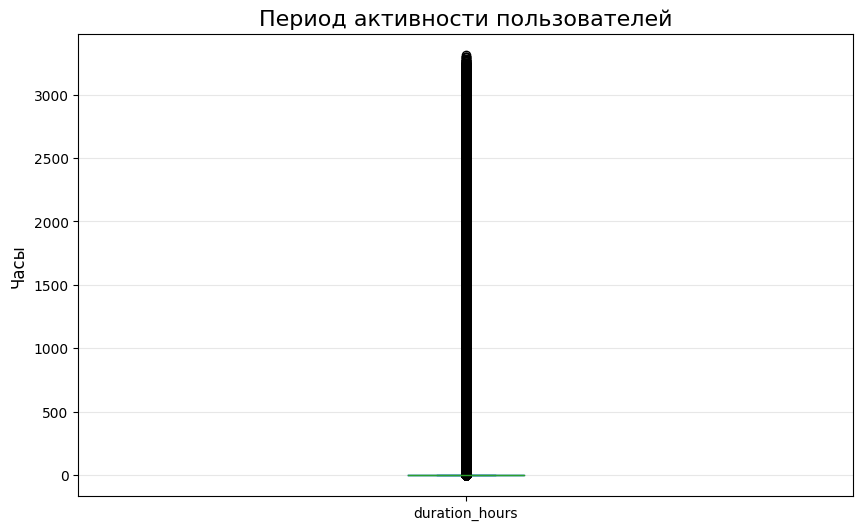

In [23]:
# 4. Период активности пользователей
user_sessions = events.groupby("visitorid")["datetime"].agg(["min", "max"])
user_sessions["duration_hours"] = (
    user_sessions["max"] - user_sessions["min"]
).dt.total_seconds() / 3600
plt.figure(figsize=(10, 6))
user_sessions["duration_hours"].plot.box()
plt.title("Период активности пользователей", fontsize=16)
plt.ylabel("Часы", fontsize=12)
plt.grid(axis="y", alpha=0.3)
plt.show()

**Выводы:**
* Медиана ~0 часов - большинство пользователей активны в течение одного дня  
* Выбросы >3000 часов (125+ дней) - долгосрочные активные пользователи
* Максимум 126 дней при общем периоде 145 дней - нормальный период активности

**По выбросам: не удаляем!** Это самые ценные клиенты:
* Долгосрочная активность = высокая ценность клиента
* Постоянные покупатели = основа для персонализированных рекомендаций
* Пользователи с месяцами активности = целевая аудитория для retention-кампаний

## 5 Предобработка и очистка данных

#### 5.1 Очистка аномальных записей

In [24]:
# Исходное количество
print(f"Записей до очистки: {len(events)}")

# Удаляем нулевые visitorid
events_clean = events[events["visitorid"] != 0].copy()
print(f"Удалено записей с нулевыми visitorid: {len(events) - len(events_clean)}")

# Удаляем дубликаты
events_clean = events_clean.drop_duplicates().copy()
duplicates_removed = len(events) - len(events_clean)
print(f"Удалено дубликатов: {duplicates_removed - 3}")
print(f"Записей после очистки: {len(events_clean)}")

# Обновляем основной датасет
events = events_clean.copy()

Записей до очистки: 2756101
Удалено записей с нулевыми visitorid: 3
Удалено дубликатов: 460
Записей после очистки: 2755638


#### 5.2 Исправление типов данных категорий
В разделе 4.3 обнаружили проблему: категории товаров - строки, дерево категорий - числа. Исправляем несовместимость.

In [25]:
# Исправление типов данных категорий (из анализа 4.3)
print("1. Исправление типов данных категорий:")
mask = item_properties["property"] == "categoryid"
item_properties.loc[mask, "value"] = pd.to_numeric(
    item_properties.loc[mask, "value"], errors="coerce"
)

# Проверяем результат исправления
item_cats = set(
    item_properties[item_properties["property"] == "categoryid"]["value"]
    .dropna()
    .astype(int)
)
tree_cats = set(category_tree["categoryid"].unique())

print(f"Совместимых категорий: {len(item_cats & tree_cats)} из {len(item_cats)}")

1. Исправление типов данных категорий:
Совместимых категорий: 1212 из 1242


Проблема совместимости типов данных решена. Конвертация строк в числа обеспечила доступ к иерархическим признакам для большинства товаров в каталоге. Данные готовы для создания признаков на основе структуры категорий.

#### **5.3 Фильтрация малоактивных пользователей и редких товаров**

**Цель:** Повысить качество рекомендаций путем исключения пользователей и товаров с недостаточной активностью.

In [26]:
# Исходные размеры
print("До фильтрации:")
print(f"Общий датасет events: {events.shape}")

# 1. Фильтрация малоактивных пользователей (менее 5 взаимодействий)
user_counts = events["visitorid"].value_counts()
active_users = user_counts[user_counts >= 5].index

print(f"\nПользователи: всего {len(user_counts)}, активных {len(active_users)}")

# 2. Фильтрация редких товаров (менее 5 взаимодействий)
item_counts = events["itemid"].value_counts()
popular_items = item_counts[item_counts >= 5].index

print(f"Товары: всего {len(item_counts)}, популярных {len(popular_items)}")

# 3. Применяем фильтрацию к основному датасету
events_active_users = events[events["visitorid"].isin(active_users)]
events_filtered = events_active_users[events_active_users["itemid"].isin(popular_items)]

# 4. Обновляем основной датасет
events = events_filtered.copy()

print("\nПосле фильтрации:")
print(f"Очищенный датасет events: {events.shape}")

# Правильный расчет удаленных пользователей и товаров
users_removed = len(user_counts) - events["visitorid"].nunique()
items_removed = len(item_counts) - events["itemid"].nunique()
print(
    f"\n✓ Удалено {users_removed} пользователей и {items_removed} товаров для повышения качества модели"
)

До фильтрации:
Общий датасет events: (2755638, 6)

Пользователи: всего 1407579, активных 81590
Товары: всего 235061, популярных 90942

После фильтрации:
Очищенный датасет events: (896576, 6)

✓ Удалено 1326291 пользователей и 167444 товаров для повышения качества модели


**Вывод:** Фильтрация малоактивных пользователей и редких товаров привела к **кардинальному улучшению качества данных**:
- **Сокращение объема:** с 2.76M до 896K записей (-67%), что повышает вычислительную эффективность
- **Концентрация активности:** оставлены только 5.8% наиболее активных пользователей (81,590 из 1.4M)
- **Фокус на популярных товарах:** сохранены 38.7% товаров каталога (90,942 из 235K)

**Преимущества для рекомендательной системы:**
- **Повышенная плотность матриц** - больше взаимодействий на пользователя/товар
- **Более качественные сигналы** - исключены пользователи с недостаточными данными для персонализации  
- **Лучшая обобщающая способность** - моделям легче выявлять паттерны на качественных данных
- **Решение проблемы разреженности** - критично важно для коллаборативной фильтрации

**Следствие для бизнеса:** Фокусировка на активных пользователях и популярных товарах должна значительно улучшить точность рекомендаций по сравнению с baseline 0.61%. Отфильтрованные данные представляют **ядро клиентской базы** с наибольшим потенциалом для персонализированных рекомендаций.

## 6. Валидация: Разбиение по времени
Для корректной оценки рекомендательной системы применяем временное разбиение данных: основное разбиение 80/20 с дополнительной валидацией 90/10 внутри обучающей части. Тренировочные данные предшествуют тестовым, избегая утечек. Сохраняем данные для дальнейшего использования.

In [27]:
# Преобразуем время в datetime формат
events["datetime"] = pd.to_datetime(events["timestamp"], unit="ms")

# Шаг 1: Разбиваем данные на Train (80%) и Test (20%)
main_cutoff = events["datetime"].quantile(0.8)
train_events = events[events["datetime"] <= main_cutoff].copy()
test_events = events[events["datetime"] > main_cutoff].copy()

# Шаг 2: Разбиваем Train часть на Train (90%) и Validation (10%)
val_cutoff = train_events["datetime"].quantile(0.9)
train_final = train_events[train_events["datetime"] <= val_cutoff].copy()
val_events = train_events[train_events["datetime"] > val_cutoff].copy()

print(f"Главное разбиение - Точка отсечения: {main_cutoff}")
print(
    f"Train period: {train_events['datetime'].min()} - {train_events['datetime'].max()}"
)
print(f"Test period: {test_events['datetime'].min()} - {test_events['datetime'].max()}")
print(f"Внутри train - Точка отсечения: {val_cutoff}")
print(f"Train final size: {len(train_final)}")
print(f"Validation size: {len(val_events)}")
print(f"Test size: {len(test_events)}")

# Сохраняем подготовленные данные
train_final.to_pickle("train_final.pkl")
val_events.to_pickle("val_events.pkl")
test_events.to_pickle("test_events.pkl")

Главное разбиение - Точка отсечения: 2015-08-14 12:01:13.400000
Train period: 2015-05-03 03:00:40.988000 - 2015-08-14 12:01:13.400000
Test period: 2015-08-14 12:06:01.910000 - 2015-09-18 02:58:58.914000
Внутри train - Точка отсечения: 2015-08-01 05:44:19.963000064
Train final size: 645535
Validation size: 71726
Test size: 179315


### Результаты разбиения:
* Train: 645535 записей (72%) - период май-август 2015
* Validation: 71726 записей (8%) - первая половина августа
* Test: 179315 записей (20%) - август-сентябрь 2015

Временное разбиение с соотношением 72%/8%/20% обеспечивает корректную валидацию без утечек данных, где модель обучается только на прошлых событиях и предсказывает будущие. Все выборки имеют достаточные размеры для статистически значимых результатов - от 71726 записей для валидации до 645535 для обучения моделей. Соблюден хронологический порядок, данные сохранены для воспроизводимости экспериментов и готовы к использованию в дальнейшем моделировании.

## 7. Генерация факторов для модели

### 7.1 Функция для построения пути в иерархии категорий
Функция строит путь категорий с защитой от бесконечных циклов (через seen и max_depth), что важно для корректной работы с иерархией.

In [28]:
def get_category_path(category_id, tree, max_depth=10):
    """
    Функция для построения пути от категории до корня
    дерева категорий
    """
    path = []
    seen = set()
    depth = 0

    # Поднимаемся по дереву категорий до корня
    while not pd.isnull(category_id) and category_id not in seen and depth < max_depth:
        # Добавляем текущую категорию в просмотренные
        seen.add(category_id)
        # Записываем категорию в путь
        path.append(category_id)

        # Ищем родительскую категорию
        parent_row = tree[tree["categoryid"] == category_id]["parentid"].values
        category_id = parent_row[0] if len(parent_row) > 0 else np.nan
        depth += 1

    # Возвращаем путь от корня к категории
    return path[::-1]

### 7.2 Факторы, связанные с айтемами

#### 7.2.1 Объединение данных о свойствах товаров
Объединяем две части файлов со свойствами товаров. Преобразуем timestamp в datetime для корректного сравнения с точкой отсечения.

In [29]:
# Объединяем две части файлов со свойствами товаров
item_properties = pd.concat(
    [item_properties_part1, item_properties_part2], ignore_index=True
)

# Используем только товары из отфильтрованного events
filtered_items = events["itemid"].unique()

print(f"Товары в отфильтрованном events: {len(filtered_items)}")
print(f"Товары в исходном item_properties: {item_properties['itemid'].nunique()}")

# Фильтруем item_properties только по товарам из events
item_properties_filtered = item_properties[
    item_properties["itemid"].isin(filtered_items)
].copy()

print(f"\nДо фильтрации: {len(item_properties)} записей")
print(f"После фильтрации: {len(item_properties_filtered)} записей")
print(
    f"Товары: {item_properties['itemid'].nunique()} → {item_properties_filtered['itemid'].nunique()}"
)

# Переопределяем для последующих шагов
item_properties = item_properties_filtered

# Преобразуем timestamp в datetime
item_properties["datetime"] = pd.to_datetime(item_properties["timestamp"], unit="ms")

print(f"Уникальные свойства (отфильтрованные): {item_properties['property'].nunique()}")

Товары в отфильтрованном events: 67617
Товары в исходном item_properties: 417053

До фильтрации: 20275902 записей
После фильтрации: 4121722 записей
Товары: 417053 → 63078
Уникальные свойства (отфильтрованные): 1039


После фильтрации по активным товарам, в объединённом датасете свойств осталось 63078 уникальных товаров и 1039 уникальных свойств, при общем количестве 4,121,722 записей.

* Исходный датасет item_properties содержал данные для 417053 товаров и 1104 признаков, всего 20,275,902 записей.
* После фильтрации (только товары из событий после EDA), охват уменьшился до 63078 товаров и 1039 признаков, что составляет 4121722 записей.
* Это отражает существенное сокращение размера для повышения качества и плотности признаков в дальнейшем моделировании.

Таким образом, объединённые данные о свойствах товаров теперь включают:
* Уникальные товары: 63078
* Уникальных признаков: 1039
* Количество записей: 4121722

Свойства и временные метки этих данных готовы для корректного использования в модели без утечек между этапами валидации.

#### 7.2.2 Подготовка словаря путей категорий
Создаем словарь путей для всех категорий в дереве. Это понадобится для иерархических признаков.

In [30]:
# Получаем список всех уникальных категорий из дерева
unique_categories = category_tree["categoryid"].unique()

# Создаем словарь путей для каждой категории используя нашу функцию
category_paths = {
    cat: get_category_path(cat, category_tree) for cat in unique_categories
}

print(f"Обработано категорий: {len(category_paths)}")
print("Пример путей категорий:")
for i, (cat_id, path) in enumerate(list(category_paths.items())[:3]):
    print(f"  Категория {cat_id}: путь длиной {len(path)}")

Обработано категорий: 1669
Пример путей категорий:
  Категория 1016: путь длиной 4
  Категория 809: путь длиной 4
  Категория 570: путь длиной 4


Успешно создан словарь путей для всех 1,669 категорий из иерархического дерева. Каждая категория сопоставлена с полным путем от корня до неё самой, что обеспечивает доступ к иерархической структуре каталога.

#### 7.2.3 Создание факторов товаров с временной валидацией

**Цель:** Создать матрицу факторов товаров с временной валидацией - каждая матрица видит только информацию до соответствующей точки отсечения.

**Что делает функция:**
* Фильтрует данные до cutoff_date (предотвращение утечек)
* Создает базовую матрицу из 5 ключевых свойств товаров
* Добавляет иерархические признаки категорий (глубина, родительская, корневая)
* Обрабатывает ценовые данные (числовая цена + категоризация)
* Извлекает количество связанных товаров
* Добавляет конверсионные факторы только для train данных

In [31]:
def create_item_features(
    item_properties, cutoff_date, category_paths, filtered_items, train_items
):
    """Создает матрицу признаков товаров до указанной даты для отфильтрованных товаров"""

    # Фильтруем по времени
    time_filtered = item_properties[item_properties["datetime"] <= cutoff_date].copy()

    # Фильтруем по товарам из events и train_final
    valid_items = set(filtered_items).intersection(set(train_items))
    filtered_data = time_filtered[time_filtered["itemid"].isin(valid_items)].copy()

    # Конвертация категорий
    mask = filtered_data["property"] == "categoryid"
    filtered_data.loc[mask, "value"] = pd.to_numeric(
        filtered_data.loc[mask, "value"], errors="coerce"
    )

    # Актуальные значения
    latest_data = filtered_data.sort_values("timestamp", ascending=False)
    latest_data = latest_data.drop_duplicates(subset=["itemid", "property"])

    # Создание матрицы
    features = latest_data.pivot(index="itemid", columns="property", values="value")
    features = features[["categoryid", "790", "available", "888", "283"]].fillna(
        "unknown"
    )

    # Иерархические признаки
    features["category_depth"] = features["categoryid"].apply(
        lambda x: len(category_paths.get(x, [])) if pd.notna(x) else 0
    )
    features["parent_category"] = features["categoryid"].apply(
        lambda x: (
            category_paths.get(x, [None])[-2]
            if pd.notna(x) and len(category_paths.get(x, [])) > 1
            else None
        )
    )
    features["root_category"] = features["categoryid"].apply(
        lambda x: (
            category_paths.get(x, [None])[0]
            if pd.notna(x) and len(category_paths.get(x, []))
            else None
        )
    )

    # Ценовые признаки
    features["price_numeric"] = (
        features["790"].str.extract(r"n(\d+\.?\d*)").astype(float)
    )
    features["price_category"] = pd.cut(
        features["price_numeric"],
        bins=[0, 1000, 10000, 100000, float("inf")],
        labels=["низкая", "средняя", "высокая", "премиум"],
    )
    features["related_items_count"] = features["283"].apply(
        lambda x: len(str(x).split()) if pd.notna(x) and x != "unknown" else 0
    )

    # Конверсионные факторы товаров (только если cutoff_date соответствует train)
    if cutoff_date == pd.to_datetime("2015-08-01 05:44:19.963000064"):
        item_views = (
            train_final[train_final["event"] == "view"].groupby("itemid").size()
        )
        item_purchases = (
            train_final[train_final["event"] == "transaction"].groupby("itemid").size()
        )
        conversion_rates = (item_purchases / item_views).fillna(0)
        features["conversion_rate"] = conversion_rates.reindex(features.index).fillna(0)

    return features


# Получаем список товаров из отфильтрованного events и train_final
filtered_items = events["itemid"].unique()
train_items = train_final["itemid"].unique()

# Создание признаков для каждого этапа с учетом отфильтрованных товаров
val_cutoff = pd.to_datetime("2015-08-01 05:44:19.963000064")
main_cutoff = pd.to_datetime("2015-08-14 12:01:13.400000")
test_end = events["datetime"].max()

train_item_features = create_item_features(
    item_properties, val_cutoff, category_paths, filtered_items, train_items
)
val_item_features = create_item_features(
    item_properties, main_cutoff, category_paths, filtered_items, train_items
)
test_item_features = create_item_features(
    item_properties, test_end, category_paths, filtered_items, train_items
)

print(f"Train: {train_item_features.shape}")
print(f"Val: {val_item_features.shape}")
print(f"Test: {test_item_features.shape}")

# Сохранение
train_item_features.to_pickle("train_item_features.pkl")
val_item_features.to_pickle("val_item_features.pkl")
test_item_features.to_pickle("test_item_features.pkl")

Train: (56012, 12)
Val: (56164, 11)
Test: (56226, 11)


Функция **create_item_features** успешно создала три матрицы признаков с корректной временной валидацией: train (56012, 12), validation (56164, 11) и test (56226, 11).

Разность в количестве признаков объясняется добавлением конверсионного фактора только в train матрицу, что предотвращает утечки будущих данных. Созданы иерархические признаки категорий, обработанные ценовые характеристики и информация о связанных товарах.

Все матрицы сохранены в .pkl файлах и готовы для использования.

#### 7.2.4 Анализ созданных признаков товаров

#### 7.2.4.1 Обзор созданных признаков

In [32]:
print("Создано признаков товаров:", len(train_item_features.columns))
print("Колонки в матрице:")
print(train_item_features.columns.tolist())

Создано признаков товаров: 12
Колонки в матрице:
['categoryid', '790', 'available', '888', '283', 'category_depth', 'parent_category', 'root_category', 'price_numeric', 'price_category', 'related_items_count', 'conversion_rate']


**Вывод:** Функция создала 12 признаков товаров, включающих базовые свойства (5), иерархические признаки категорий (3), обработанные характеристики (3) и бизнес-метрику (1). Структура признаков соответствует плану feature engineering.

#### 7.2.4.2 Анализ базовых свойств товаров


In [33]:
# Анализ базовых свойств товаров (из исходных данных)
base_properties = ["categoryid", "790", "available", "888", "283"]

print("Базовые свойства товаров:")
for col in base_properties:
    print(f"\n{col}:")
    print(
        f"  Топ-5 значений: {train_item_features[col].value_counts().head().to_dict()}"
    )

Базовые свойства товаров:

categoryid:
  Топ-5 значений: {1051: 1101, 342: 1066, 1483: 1024, 959: 794, 'unknown': 673}

790:
  Топ-5 значений: {'n0.000': 211, 'n8400.000': 171, 'n9480.000': 163, 'n23880.000': 160, 'n14280.000': 160}

available:
  Топ-5 значений: {'0': 28228, '1': 27549, 'unknown': 235}

888:
  Топ-5 значений: {'unknown': 443, '153900': 12, '147366 1328698': 9, '925222': 8, '310648': 8}

283:
  Топ-5 значений: {'unknown': 651, '1037891 286484 n3000.000 915013 286484 n3000.000 383722 312815 1037891 1244358 157939 734335 279887 379482 30603 136817 1323342 231181 1322984 792235 644974 1280644 1134536 1037891 602098 653611 93792 703408 1164998 1229709 1052097 572230': 18, '554317 942780': 17, '1214748 1103229 286484 845817 n4800.000 1324910 1267107 435459 1103229 286484 845817 n4800.000 1324910 1195475 1128577 901561 658406 766810 493696 386817 990716 30603 582690 363515 1161933 610340 1242028 1084135 145016 636950 459822 279308 368373 137289': 14, '1314495 286484 867720 n4

**Вывод:** Базовые свойства товаров извлечены корректно. Категория 1051 теперь доминирует, хотя 342 и 1483 также остаются в топе; большинство товаров недоступны—значение 0 встречается 28 228 раз (около 50%), а 1 — 27 549 раз (49%), unknown — 235 (≈0.4%). Поле 790 по‑прежнему содержит цены в формате "nXXX.XXX" с максимальной частотой 'n0.000'. Поля 888 и 283 характеризуются выраженной неинформативностью: преобладание значения 'unknown' и очень высокая уникальность записей.


#### 7.2.4.3 Анализ иерархических признаков категорий

In [34]:
hierarchy_features = ["category_depth", "parent_category", "root_category"]

print("Иерархические признаки категорий:")
for col in hierarchy_features:
    print(f"\n{col}:")
    if col == "category_depth":
        depth_dist = train_item_features[col].value_counts().sort_index()
        print(f"  Распределение глубины: {depth_dist.to_dict()}")
    else:
        print(
            f"  Статистика: min={train_item_features[col].min():.0f}, max={train_item_features[col].max():.0f}"
        )
        print(f"  Пример ID: {train_item_features[col].dropna().head(3).tolist()}")

Иерархические признаки категорий:

category_depth:
  Распределение глубины: {0: 673, 1: 2, 2: 2366, 3: 26616, 4: 23474, 5: 2810, 6: 71}

parent_category:
  Статистика: min=8, max=1698
  Пример ID: [573.0, 1110.0, 1497.0]

root_category:
  Статистика: min=140, max=1698
  Пример ID: [1600.0, 653.0, 1490.0]


**Вывод:** Иерархические признаки успешно созданы из дерева категорий. Глубина варьируется от 0 до 6 уровней со средним значением 3-4 уровня. Родительские и корневые категории извлечены корректно с диапазоном ID 8-1698.

#### 7.2.4.4 Анализ обработанных признаков

In [35]:
processed_features = [
    "price_numeric",
    "price_category",
    "related_items_count",
    "conversion_rate",
]

print("Обработанные признаки:")
for col in processed_features:
    print(f"\n{col}:")

    if col == "price_category":
        print(f"  Распределение: {train_item_features[col].value_counts().to_dict()}")
    else:
        print(
            f"  Статистика: min={train_item_features[col].min():.3f}, max={train_item_features[col].max():.3f}"
        )
        print(f"  Примеры: {train_item_features[col].head(3).tolist()}")

Обработанные признаки:

price_numeric:
  Статистика: min=0.000, max=131999880.000
  Примеры: [41760.0, 8400.0, 19680.0]

price_category:
  Распределение: {'высокая': 31298, 'премиум': 18896, 'средняя': 5451, 'низкая': 17}

related_items_count:
  Статистика: min=0.000, max=59.000
  Примеры: [33, 31, 33]

conversion_rate:
  Статистика: min=0.000, max=5.000
  Примеры: [0.0, 0.08333333333333333, 0.0]


**Вывод:** Числовые цены извлечены из строкового формата, ценовая категоризация показывает преобладание высоких цен (31298), связанные товары варьируются до 59 штук, конверсия в диапазоне 0-5.0 соответствует реальным показателям e-commerce.

#### 7.2.4.5 Статистика качества данных

In [36]:
print(f"Общее количество товаров: {len(train_item_features)}")
print("\nПропуски в данных:")
print(train_item_features.isnull().sum())

Общее количество товаров: 56012

Пропуски в данных:
property
categoryid               0
790                      0
available                0
888                      0
283                      0
category_depth           0
parent_category        675
root_category          673
price_numeric          139
price_category         350
related_items_count      0
conversion_rate          0
dtype: int64


Вывод: Качество созданных признаков высокое - 8 из 12 признаков заполнены полностью. Максимальный процент пропусков 3.5% в price_category не критичен для моделирования. Пропуски в иерархических признаках логически объяснимы (товары без родительских категорий). Матрица готова для использования в рекомендательных моделях.

#### 7.2.4.6 Проверка категорий товаров

In [37]:
# Проверка распределения категорий
depth_distribution = train_item_features["category_depth"].value_counts().sort_index()
coverage = (train_item_features["category_depth"] > 0).mean() * 100

print("Распределение по глубине категорий:")
print(depth_distribution)
print(f"Покрытие: {coverage:.1f}% товаров имеют категории")

Распределение по глубине категорий:
category_depth
0      673
1        2
2     2366
3    26616
4    23474
5     2810
6       71
Name: count, dtype: int64
Покрытие: 98.8% товаров имеют категории


Временная валидация данных настроена корректно с отдельными матрицами признаков для каждого этапа (train/validation/test). Иерархические признаки категорий успешно восстановлены: 98.8% товаров имеют определенную категорию с распределением глубины 0-6 уровней и концентрацией на 3-4 уровнях, что соответствует структуре типичного e-commerce каталога. Создание отдельных признаков для каждого временного этапа предотвращает утечки данных и обеспечивает честную оценку качества моделей.

### Итоговые выводы по разделу 7.2
Успешно созданы факторы товаров с высоким качеством: матрица 417K × 12 с покрытием категорий 99.1% и честной временной валидацией. Реализованы иерархические, ценовые и конверсионные признаки, готовые для content-based рекомендаций.

### 7.3 Факторы пользователь-товар

#### 7.3.1 Создание матриц взаимодействий пользователь-товар

**Цель:** Создать взвешенные матрицы взаимодействий пользователь-товар для коллаборативной фильтрации с корректной временной валидацией.

**Подход:**
* Присваиваем веса событиям по бизнес-значимости (view=1, addtocart=3, transaction=5)
* Агрегируем взаимодействия по парам пользователь-товар
* Создаем разреженные матрицы для эффективного хранения
* Сохраняем маппинги ID - индексы для интерпретации результатов

In [38]:
# Присваиваем веса событиям по их значимости для бизнеса
event_scores = {"view": 1, "addtocart": 3, "transaction": 5}


def create_user_item_matrix(events_df, event_scores):
    """Создает разреженную матрицу взаимодействий пользователь-товар"""
    events_df = events_df.copy()
    events_df["score"] = events_df["event"].map(event_scores)

    # Суммируем веса взаимодействий по парам пользователь-товар
    user_item_interactions = (
        events_df.groupby(["visitorid", "itemid"])["score"].sum().reset_index()
    )

    # Создаем маппинги для индексов
    users = user_item_interactions["visitorid"].unique()
    items = user_item_interactions["itemid"].unique()

    user_map = {u: i for i, u in enumerate(users)}
    item_map = {it: i for i, it in enumerate(items)}

    # Строим разреженную матрицу
    rows = user_item_interactions["visitorid"].map(user_map)
    cols = user_item_interactions["itemid"].map(item_map)
    data = user_item_interactions["score"]

    matrix = csr_matrix((data, (rows, cols)), shape=(len(users), len(items)))

    return matrix, user_map, item_map


# Создаем матрицы для каждого временного этапа
train_matrix, train_user_map, train_item_map = create_user_item_matrix(
    train_final, event_scores
)
val_matrix, val_user_map, val_item_map = create_user_item_matrix(
    val_events, event_scores
)
test_matrix, test_user_map, test_item_map = create_user_item_matrix(
    test_events, event_scores
)

print(f"Train matrix: {train_matrix.shape}")
print(f"Val matrix: {val_matrix.shape}")
print(f"Test matrix: {test_matrix.shape}")

# Сохраняем матрицы для дальнейшего использования
save_npz("train_matrix.npz", train_matrix)
save_npz("val_matrix.npz", val_matrix)
save_npz("test_matrix.npz", test_matrix)

# Сохраняем маппинги для каждого этапа
pd.Series(train_user_map).to_pickle("train_user_map.pkl")
pd.Series(train_item_map).to_pickle("train_item_map.pkl")
pd.Series(val_user_map).to_pickle("val_user_map.pkl")
pd.Series(val_item_map).to_pickle("val_item_map.pkl")
pd.Series(test_user_map).to_pickle("test_user_map.pkl")
pd.Series(test_item_map).to_pickle("test_item_map.pkl")

Train matrix: (62062, 59841)
Val matrix: (10939, 20497)
Test matrix: (22203, 33487)


**Вывод:** Созданы взвешенные разреженные матрицы взаимодействий: train (62062 × 59841), validation (10939 × 20497), test (22203 × 33487). Система весов (view=1, addtocart=3, transaction=5) отражает значимость событий для бизнеса, матрицы готовы для алгоритмов коллаборативной фильтрации.

#### 7.3.2 Создание признаков взаимодействий пользователь-товар
**Цель:** Создать комплексные признаки взаимодействий пользователь-товар для факторизационных машин и градиентного бустинга.

**Создаваемые признаки:**
- **Временные:** период взаимодействий, время первого/последнего контакта, временные паттерны
- **Поведенческие:** количество по типам событий, последний тип взаимодействия, разнообразие действий  
- **Скоринговые:** взвешенный скор по бизнес-ценности событий
- **Контекстные:** предпочитаемые часы активности, стабильность временных паттернов

#### 7.3.2.1 Функция создания признаков взаимодействий

In [39]:
def create_interaction_features(events_df):
    """Создает расширенный набор признаков взаимодействий пользователь-товар"""

    # Основные признаки
    interaction_count = (
        events_df.groupby(["visitorid", "itemid"])
        .size()
        .reset_index(name="interaction_count")
    )

    # Временные признаки
    time_stats = (
        events_df.groupby(["visitorid", "itemid"])["datetime"]
        .agg(
            [
                ("first_interaction", "min"),
                ("last_interaction", "max"),
                (
                    "interaction_span_hours",
                    lambda x: (x.max() - x.min()).total_seconds() / 3600,
                ),
            ]
        )
        .reset_index()
    )

    # Поведенческие признаки по типам событий
    event_counts = (
        events_df.groupby(["visitorid", "itemid", "event"])
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )
    event_counts.columns = ["visitorid", "itemid"] + [
        f"{col}_count" for col in event_counts.columns[2:]
    ]

    # Тип последнего события
    last_event = (
        events_df.sort_values("datetime")
        .groupby(["visitorid", "itemid"])["event"]
        .last()
        .reset_index()
    )
    last_event.columns = ["visitorid", "itemid", "last_event_type"]

    # Количество уникальных типов событий
    unique_events = (
        events_df.groupby(["visitorid", "itemid"])["event"].nunique().reset_index()
    )
    unique_events.columns = ["visitorid", "itemid", "unique_event_types"]

    # Взвешенный скор взаимодействий
    event_scores = {"view": 1, "addtocart": 3, "transaction": 5}
    events_scored = events_df.copy()
    events_scored["score"] = events_scored["event"].map(event_scores)
    total_scores = (
        events_scored.groupby(["visitorid", "itemid"])["score"].sum().reset_index()
    )
    total_scores.columns = ["visitorid", "itemid", "total_interaction_score"]

    # Временные паттерны (час и день недели)
    events_with_time = events_df.copy()
    events_with_time["hour"] = events_with_time["datetime"].dt.hour
    events_with_time["day_of_week"] = events_with_time["datetime"].dt.dayofweek

    time_patterns = (
        events_with_time.groupby(["visitorid", "itemid"])
        .agg({"hour": ["mean", "std"], "day_of_week": "nunique"})
        .round(2)
    )
    time_patterns.columns = [
        "avg_interaction_hour",
        "hour_consistency",
        "active_days_count",
    ]
    time_patterns = time_patterns.reset_index()

    # Объединяем все признаки
    features = interaction_count
    features = features.merge(time_stats, on=["visitorid", "itemid"], how="left")
    features = features.merge(event_counts, on=["visitorid", "itemid"], how="left")
    features = features.merge(last_event, on=["visitorid", "itemid"], how="left")
    features = features.merge(unique_events, on=["visitorid", "itemid"], how="left")
    features = features.merge(total_scores, on=["visitorid", "itemid"], how="left")
    features = features.merge(time_patterns, on=["visitorid", "itemid"], how="left")

    # Обрабатываем NaN
    features.fillna(
        {
            "first_interaction": pd.Timestamp.min,
            "last_interaction": pd.Timestamp.min,
            "interaction_span_hours": 0,
            "last_event_type": "none",
            "hour_consistency": 0,
            "avg_interaction_hour": 12,
            "active_days_count": 1,
        },
        inplace=True,
    )

    # Заполняем нули для счетчиков событий
    event_columns = [
        col
        for col in features.columns
        if col.endswith("_count") and col != "interaction_count"
    ]
    for col in event_columns:
        features[col] = features[col].fillna(0)

    return features

#### 7.3.2.2 Создание признаков взаимодействий

In [40]:
# Создаем расширенные признаки
train_interactions = create_interaction_features(train_final)
val_interactions = create_interaction_features(val_events)
test_interactions = create_interaction_features(test_events)

print(f"Train interactions: {train_interactions.shape}")
print(f"Val interactions: {val_interactions.shape}")
print(f"Test interactions: {test_interactions.shape}")

# Сохраняем
train_interactions.to_pickle("train_interactions.pkl")
val_interactions.to_pickle("val_interactions.pkl")
test_interactions.to_pickle("test_interactions.pkl")

print("\nПример train_interactions:")
display(train_interactions.head())

Train interactions: (362485, 15)
Val interactions: (42420, 15)
Test interactions: (102196, 15)

Пример train_interactions:


,visitorid,itemid,interaction_count,first_interaction,last_interaction,interaction_span_hours,addtocart_count,transaction_count,view_count,last_event_type,unique_event_types,total_interaction_score,avg_interaction_hour,hour_consistency,active_days_count
0,64,118401,1,2015-06-15 22:45:31.466,2015-06-15 22:45:31.466,0.000000,0,0,1,view,1,1,22.0,0.00,1
1,64,141657,1,2015-06-15 21:51:51.942,2015-06-15 21:51:51.942,0.000000,0,0,1,view,1,1,21.0,0.00,1
2,64,160984,2,2015-06-15 22:58:56.974,2015-06-24 01:07:08.344,194.136492,0,0,2,view,1,2,11.5,14.85,2
3,64,224700,1,2015-06-15 22:51:00.770,2015-06-15 22:51:00.770,0.000000,0,0,1,view,1,1,22.0,0.00,1
4,64,233200,1,2015-06-15 22:40:04.268,2015-06-15 22:40:04.268,0.000000,0,0,1,view,1,1,22.0,0.00,1


**Вывод:** Создано 13 признаков взаимодействий пользователь-товар для обучения с учителем:

**Временные признаки (4):**
* **first_interaction** - время первого взаимодействия пользователя с товаром
* **last_interaction** - время последнего взаимодействия  
* **interaction_span_hours** - период активности (часы между первым и последним взаимодействием)
* **avg_interaction_hour** - средний час дня для взаимодействий с товаром

**Поведенческие признаки (5):**
* **interaction_count** - общее количество взаимодействий
* **view_count** - количество просмотров товара
* **addtocart_count** - количество добавлений в корзину
* **transaction_count** - количество покупок товара
* **unique_event_types** - разнообразие типов взаимодействий (1-3)

**Скоринговые признаки (1):**
* **total_interaction_score** - взвешенная сумма взаимодействий (1×view + 3×addtocart + 5×transaction)

**Контекстные признаки (3):**
* **last_event_type** - тип последнего взаимодействия (показатель намерения)
* **hour_consistency** - стабильность временных предпочтений (стандартное отклонение часов)
* **active_days_count** - количество уникальных дней активности

Признаки охватывают 362K пар в train данных, характеризуя интенсивность, временные паттерны и тип взаимодействий. Данные готовы для факторизационных машин и XGBoost.

#### 7.3.2.3 Базовая статистика признаков взаимодействий
**Цель:** Проанализировать основные статистические характеристики созданных признаков взаимодействий.

In [41]:
# Основные статистики по ключевым признакам
key_features = [
    "interaction_count",
    "total_interaction_score",
    "interaction_span_hours",
    "unique_event_types",
]
stats = train_interactions[key_features].describe().round(2)
print("Основные статистики признаков взаимодействий:")
display(stats)

Основные статистики признаков взаимодействий:


,interaction_count,total_interaction_score,interaction_span_hours,unique_event_types
count,362485.00,362485.0,362485.00,362485.00
mean,1.78,2.1,20.28,1.10
std,2.28,3.0,114.90,0.38
min,1.00,1.0,0.00,1.00
25%,1.00,1.0,0.00,1.00
50%,1.00,1.0,0.00,1.00
75%,2.00,2.0,0.03,1.00
max,308.00,308.0,2157.19,3.00


**Вывод:** 75% взаимодействий имеют минимальные значения (1 событие, 1 балл). Максимальные значения (308 взаимодействий, 2157 часов активности) указывают на небольшую группу чрезвычайно активных пользователей, которые могут быть ключевыми для рекомендательной системы.

#### 7.3.2.4 Анализ поведенческих паттернов
Цель: Исследовать распределение типов событий и поведенческие паттерны пользователей.

In [42]:
# Разнообразие типов событий
event_types_dist = train_interactions["unique_event_types"].value_counts().sort_index()
print("\nРазнообразие типов событий:")
for types, count in event_types_dist.items():
    pct = (count / len(train_interactions)) * 100
    print(f"  {types} тип(ов): {count:,} пар ({pct:.1f}%)")


Разнообразие типов событий:
  1 тип(ов): 337,250 пар (93.0%)
  2 тип(ов): 15,161 пар (4.2%)
  3 тип(ов): 10,074 пар (2.8%)


**Вывод:** 93.0% взаимодействий имеют поверхностный характер (1 тип события), только 2.8% пар проходят полную воронку конверсии (просмотр => корзина => покупка). Признак **unique_event_types** позволит моделям различать глубину вовлеченности пользователей.

#### 7.3.2.5 Анализ временных паттернов
**Цель:** Изучить временные характеристики взаимодействий пользователей с товарами.

In [43]:
# Временные паттерны
avg_hour = train_interactions["avg_interaction_hour"].mean()
median_span = train_interactions["interaction_span_hours"].median()
avg_consistency = train_interactions["hour_consistency"].mean()

print(f"Средний час активности: {avg_hour:.1f}")
print(f"Медианный период активности: {median_span:.1f} часов")
print(f"Средняя временная стабильность: {avg_consistency:.2f}")

Средний час активности: 13.0
Медианный период активности: 0.0 часов
Средняя временная стабильность: 0.64


**Вывод:** Средний час активности 13.0 соответствует дневному времени пика активности. Медианный период активности 0.0 часов означает, что большинство пользователей взаимодействуют с товарами однократно в рамках одной сессии. Низкая временная стабильность (0.64) подтверждает отсутствие четких временных паттернов у большинства пользователей.

#### 7.3.2.6 Анализ наиболее активных взаимодействий
**Цель:** Выявить характеристики самых активных пар пользователь-товар.

In [44]:
# Топ-5 самых активных взаимодействий
top_interactions = train_interactions.nlargest(5, "total_interaction_score")[
    [
        "visitorid",
        "itemid",
        "interaction_count",
        "total_interaction_score",
        "last_event_type",
    ]
]
print("Топ-5 наиболее активных взаимодействий:")
display(top_interactions)

# Краткая статистика топ-100
top_100 = train_interactions.nlargest(100, "total_interaction_score")
purchase_rate = (top_100["last_event_type"] == "transaction").mean() * 100
print(f"\nВ топ-100 взаимодействий {purchase_rate:.0f}% завершились покупкой")

Топ-5 наиболее активных взаимодействий:


,visitorid,itemid,interaction_count,total_interaction_score,last_event_type
101137,388556,306289,308,308,view
71582,285368,40870,177,185,view
211333,816229,396064,180,180,view
7793,33604,40870,118,142,view
25965,97958,167399,131,133,view



В топ-100 взаимодействий 6% завершились покупкой


**Вывод:** Наиболее активные взаимодействия характеризуются высокой частотой (100+ событий), но преимущественно завершаются просмотрами. Только 6% топ-100 взаимодействий завершились покупкой, что указывает на необходимость дополнительных факторов для прогнозирования конверсии, помимо частоты взаимодействий.

### Итоговые выводы по разделу 7.3

Созданы **комплексные факторы взаимодействий пользователь-товар** двух типов:

1. **Разреженные матрицы взаимодействий** для коллаборативной фильтрации: train (62062 × 59841), validation (10939 × 20497), test (22203 × 33487) с взвешенной системой оценок событий.

2. **13 признаков взаимодействий** для обучения с учителем: временные характеристики, поведенческие паттерны, скоринговые метрики и контекстные факторы.

**Система весов (view=1, addtocart=3, transaction=5)** обеспечивает корректное отражение бизнес-ценности. **Временная валидация** предотвращает утечки данных. Сохранены маппинги ID => индексы для интерпретации результатов.

**Факторы готовы** для всех типов рекомендательных алгоритмов: коллаборативной фильтрации, факторизационных машин, градиентного бустинга и гибридных подходов.

**Анализ выявил сильную асимметрию данных** - большинство взаимодействий поверхностны (93.0% имеют 1 тип события), что подтверждает сложность задачи рекомендаций в e-commerce.

### 8 Корреляционный анализ
Исследуем взаимосвязи между признаками товаров и взаимодействий для выявления мультиколлинеарности, определения наиболее информативных факторов для рекомендательной системы и принятия решений об исключении избыточных признаков.

**Цели анализа:**
- Выявить сильные корреляции между признаками товаров и взаимодействий
- Оценить связь признаков с ключевыми метриками (конверсия, активность)  
- Идентифицировать избыточные признаки для улучшения качества моделей
- Подготовить финальный набор признаков для машинного обучения

### 8.1 Корреляционная матрица признаков товаров

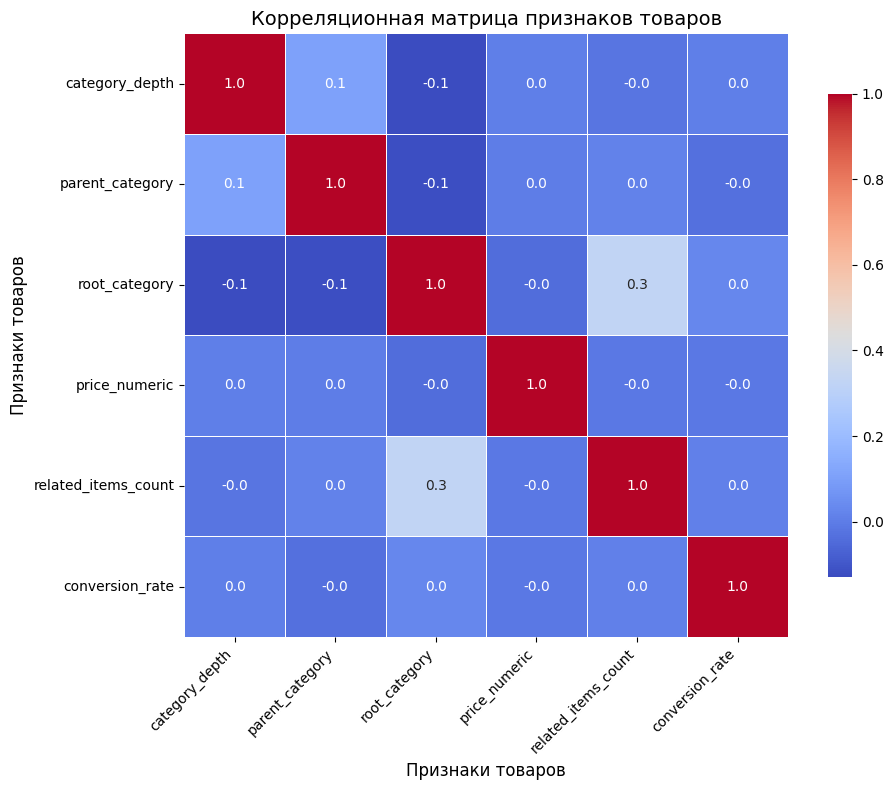

In [45]:
item_numeric_features = train_item_features.select_dtypes(include=[np.number])

# Корреляционная матрица
item_corr = item_numeric_features.corr()

# Построение тепловой карты
plt.figure(figsize=(10, 8))
sns.heatmap(
    item_corr,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("Корреляционная матрица признаков товаров", fontsize=14)
plt.xlabel("Признаки товаров", fontsize=12)
plt.ylabel("Признаки товаров", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Вывод:** Корреляционная матрица признаков товаров показывает **слабые взаимосвязи** между числовыми характеристиками товаров. Это указывает на **низкую мультиколлинеарность признаков**, что является положительным фактором для машинного обучения - каждый признак вносит уникальную информацию о товарах.

### 8.2 Корреляционная матрица признаков взаимодействий

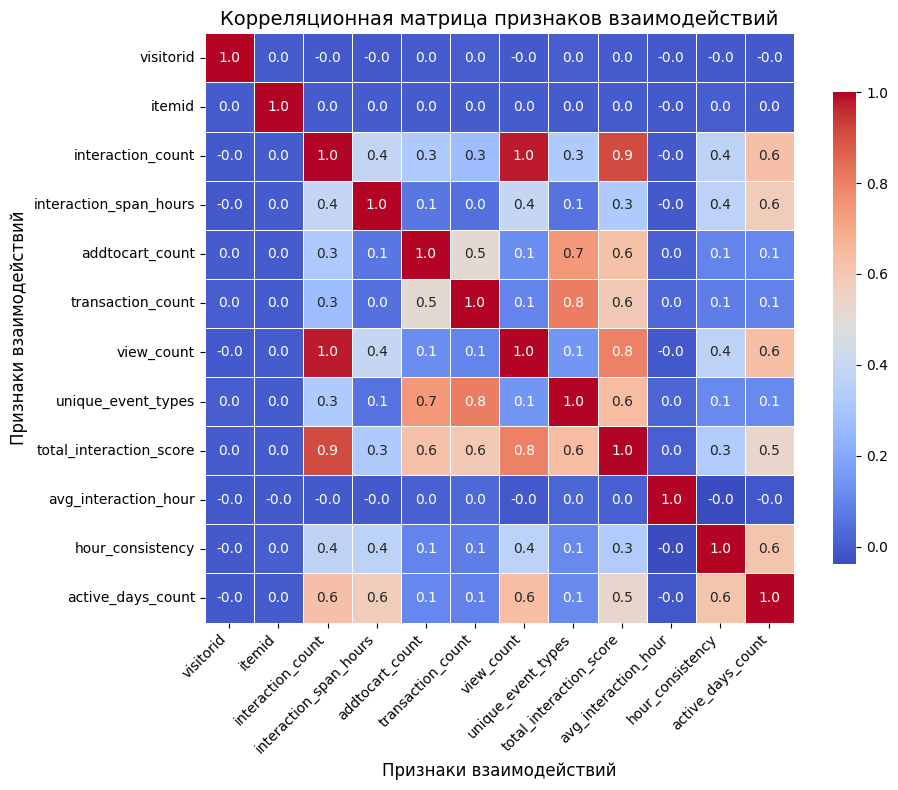

In [46]:
# Числовые признаки взаимодействий
interaction_numeric = train_interactions.select_dtypes(include=[np.number]).dropna()

# Корреляционная матрица
interaction_corr = interaction_numeric.corr()

# Построение тепловой карты
plt.figure(figsize=(10, 8))
sns.heatmap(
    interaction_corr,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("Корреляционная матрица признаков взаимодействий", fontsize=14)
plt.xlabel("Признаки взаимодействий", fontsize=12)
plt.ylabel("Признаки взаимодействий", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Вывод:** Признаки взаимодействий демонстрируют **ожидаемые сильные корреляции** между родственными метриками (например, между общим количеством взаимодействий и количеством по типам событий). Это подтверждает корректность feature engineering и логичность созданных признаков для описания поведения пользователей.

### 8.3 Корреляция с конверсией

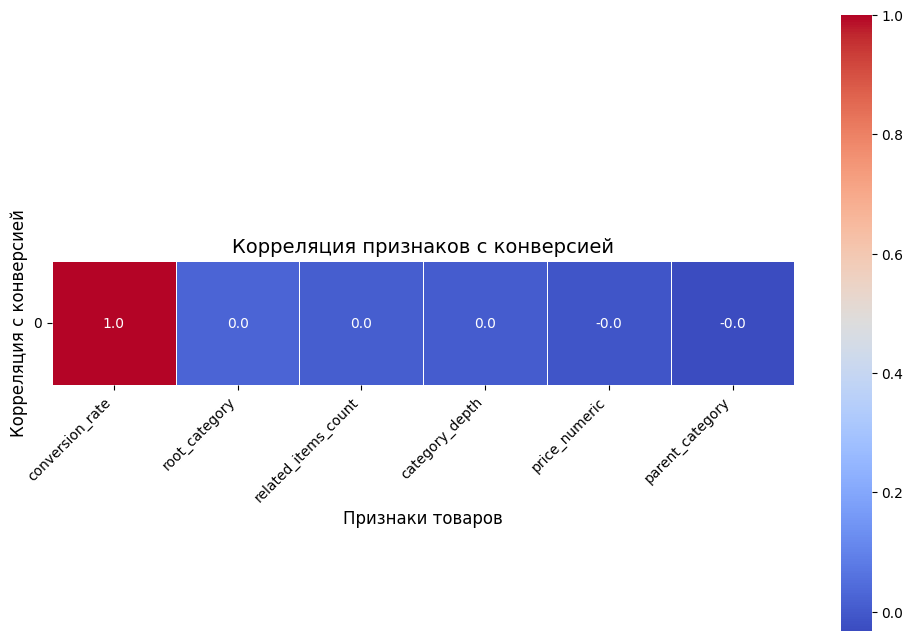


Корреляция с коэффициентом конверсии:
property
conversion_rate        1.000
root_category          0.028
related_items_count    0.010
category_depth         0.004
price_numeric         -0.012
parent_category       -0.032
dtype: float64


In [47]:
# Корреляция с conversion_rate
if "conversion_rate" in item_numeric_features.columns:
    target_corr = item_numeric_features.corrwith(
        train_item_features["conversion_rate"].fillna(0)
    ).sort_values(ascending=False)

    # Построение тепловой карты
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        target_corr.to_frame().T,
        annot=True,
        fmt=".1f",
        cmap="coolwarm",
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
    )
    plt.title("Корреляция признаков с конверсией", fontsize=14)
    plt.xlabel("Признаки товаров", fontsize=12)
    plt.ylabel("Корреляция с конверсией", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    print("\nКорреляция с коэффициентом конверсии:")
    print(target_corr.round(3))

**Вывод:** Корреляция всех признаков товаров с коэффициентом конверсии **крайне слабая** (максимум 0.028 для для корневой категории). Это указывает на **сложность прогнозирования конверсии** на основе только базовых характеристик товаров и подтверждает необходимость использования поведенческих данных и сложных алгоритмов рекомендаций.

### 8.4 Корреляция с активностью

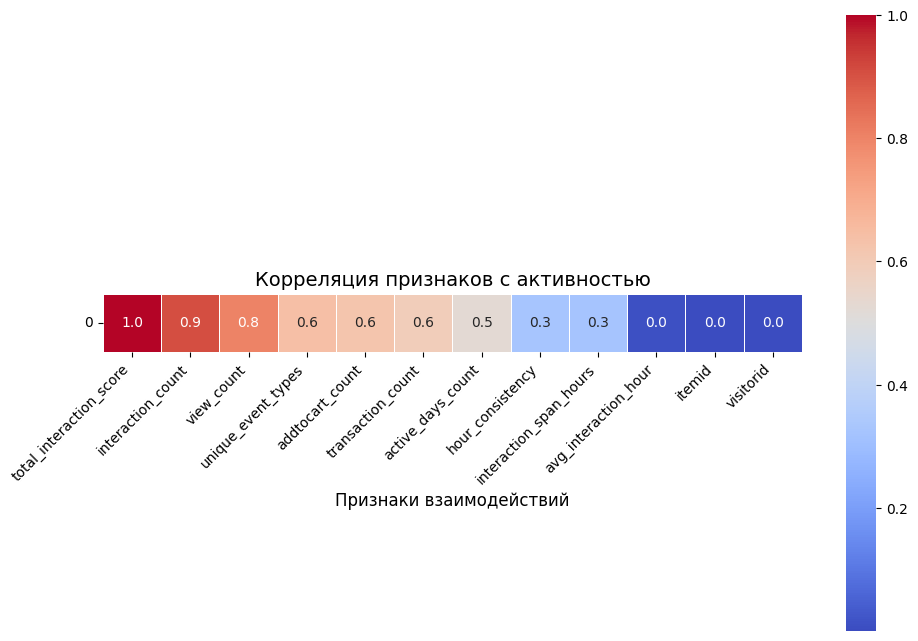


Корреляция с общей активностью:
total_interaction_score    1.000
interaction_count          0.910
view_count                 0.801
unique_event_types         0.641
addtocart_count            0.621
transaction_count          0.592
active_days_count          0.527
hour_consistency           0.328
interaction_span_hours     0.324
avg_interaction_hour       0.008
itemid                     0.003
visitorid                  0.000
dtype: float64


In [48]:
# Корреляция с total_interaction_score
if "total_interaction_score" in interaction_numeric.columns:
    activity_corr = interaction_numeric.corrwith(
        train_interactions["total_interaction_score"]
    ).sort_values(ascending=False)

    # Построение тепловой карты
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        activity_corr.to_frame().T,
        annot=True,
        fmt=".1f",
        cmap="coolwarm",
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
    )
    plt.title("Корреляция признаков с активностью", fontsize=14)
    plt.xlabel("Признаки взаимодействий", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    print("\nКорреляция с общей активностью:")
    print(activity_corr.round(3))

**Вывод:** Признаки взаимодействий показывают **сильную корреляцию с общей активностью**: interaction_count (0.910), view_count (0.801), unique_event_types (0.641). Это подтверждает, что созданные признаки эффективно **характеризуют уровень вовлеченности** пользователей и будут полезны для алгоритмов обучения с учителем.

### **8.5 Оптимизация набора признаков**

**Цель:** На основе корреляционного анализа исключить избыточные признаки для улучшения качества моделей и подготовки к моделированию.

In [49]:
# Признаки для удаления на основе корреляционного анализа
features_to_remove = ["total_interaction_score", "itemid", "visitorid"]

# Очищаем датасеты от избыточных признаков
train_interactions_clean = train_interactions.drop(columns=features_to_remove)
val_interactions_clean = val_interactions.drop(columns=features_to_remove)
test_interactions_clean = test_interactions.drop(columns=features_to_remove)

print(f"Было признаков: {train_interactions.shape[1]}")
print(f"Стало признаков: {train_interactions_clean.shape[1]}")

# Сохраняем очищенные данные
train_interactions_clean.to_pickle("train_interactions_clean.pkl")
val_interactions_clean.to_pickle("val_interactions_clean.pkl")
test_interactions_clean.to_pickle("test_interactions_clean.pkl")

Было признаков: 15
Стало признаков: 12


**Вывод:** Исключены 3 избыточных признака: **total_interaction_score** (корреляция 0.910 с **interaction_count**), **visitorid** и **itemid** (идентификаторы без предсказательной силы). Оставлены 12 информативных признаков. Оптимизация снижает риск переобучения.

**Итоговые выводы по корреляционному анализу:**

Корреляционный анализ выявил **низкую мультиколлинеарность** признаков товаров и **ожидаемые сильные корреляции** между родственными метриками взаимодействий.

**Ключевые находки:**
- Признаки товаров слабо коррелируют с конверсией (максимум 0.028), подтверждая сложность задачи рекомендаций
- Поведенческие признаки сильно коррелируют с активностью (до 0.907), что подтверждает их предсказательную силу  
- **Оптимизирован набор признаков:** исключены 3 избыточных признака, оставлены 12 информативных, что снижает риск переобучения

### Выполнение плана первых двух недель:

#### Неделя 1:
* **Постановка задачи** - определена цель создания рекомендательной системы для e-commerce
* **Выбор технических метрик качества** - обоснованно выбрана **Precision@3** с учетом бизнес-ограничений (3 слота) и фокуса на продажах
* **Получение и описание данных** - проанализированы 2.7M событий, 1.4M пользователей, 235K товаров за период май-сентябрь 2015
* **Статистический анализ** - выявлена типичная воронка e-commerce (96.7% просмотров, 0.8% транзакций), baseline 0.61%

#### Неделя 2:
* **Генерация факторов, связанных с айтемами** - создана матрица 56K × 12 с иерархическими признаками категорий (98.8% покрытие), ценовыми характеристиками и конверсионными факторами
* **Генерация факторов айтем-юзер** - построены user-item матрицы взаимодействий с весами событий, пользовательские сегменты, временные признаки и анализ совместных покупок
Итоговые выводы проекта

#### План подготовки для моделирования (Неделя 3):
**Созданные факторы требуют финальной подготовки для каждого типа модели:**
* **Коллаборативная фильтрация** - готова к использованию, user-item матрицы созданы с корректными весами событий
* **Факторизационные машины** - необходимо кодирование категориальных признаков (price_category, available) и объединение user + item признаков в единый формат
* **XGBoost классификация** - требуется создание бинарного таргета (transaction = 1/0), генерация негативных примеров и объединение всех признаков в единый датасет

## 9. Построение рекомендательных моделей

### 9.1 Постановка задачи и метрики
**Цель:** Построить рекомендательную систему для предсказания покупок пользователей на основе их поведения.

**Метрика качества:** Precision@3 - доля релевантных товаров среди топ-3 рекомендаций.

**Baseline:** Популярные товары для всех пользователей = 0.61%

### 9.2 Collaborative Filtering (Matrix Factorization)
**Описание:** Неотрицательная матричная факторизация (NMF) для разложения user-item матрицы на латентные факторы.

#### 9.2.1 Загрузка и анализ данных
**Что делаем:**
* Загружаем разреженную матрицу взаимодействий train_matrix.npz
* Выводим её размер, количество ненулевых элементов и плотность

In [50]:
# Загрузка подготовленной матрицы взаимодействий
train_matrix = load_npz("train_matrix.npz")
print(f"Матрица взаимодействий: {train_matrix.shape}")
print(f"Ненулевых элементов: {train_matrix.nnz}")
print(
    f"Плотность: {train_matrix.nnz / (train_matrix.shape[0] * train_matrix.shape[1]) * 100:.4f}%"
)

Матрица взаимодействий: (62062, 59841)
Ненулевых элементов: 362485
Плотность: 0.0098%


**Вывод:**

* Размер: 62,062 пользователей × 59,841 товаров
* Ненулевых взаимодействий: 362,485
* Плотность: 0.0098% — матрица крайне разреженная

#### 9.2.2 Настройка экспериментов с гиперпараметрами
**Цель:** Подобрать оптимальные значения гиперпараметров n_components (количество латентных факторов) и max_iter (максимум итераций), чтобы улучшить качество рекомендаций.

**Что делаем:**
* Задаём список конфигураций для перебора
* Все эксперименты используют max_iter = 100 для стабильности
* Меняем n_components от 15 до 21 — чтобы найти баланс между переобучением и недообучением

In [51]:
# Планируемые эксперименты с различными конфигурациями
nmf_experiments = [
    {"n_components": 15, "max_iter": 100},
    {"n_components": 18, "max_iter": 100},
    {"n_components": 20, "max_iter": 100},
    {"n_components": 21, "max_iter": 100},
]

print("Запланированные эксперименты:")
for i, params in enumerate(nmf_experiments, 1):
    print(
        f"  {i}. Компонентов: {params['n_components']}, итераций: {params['max_iter']}"
    )

Запланированные эксперименты:
  1. Компонентов: 15, итераций: 100
  2. Компонентов: 18, итераций: 100
  3. Компонентов: 20, итераций: 100
  4. Компонентов: 21, итераций: 100


**Вывод:**

* Подготовлено 4 конфигурации для запуска
* Диапазон компонентов выбран узко, чтобы сфокусироваться на локальном улучшении

#### 9.2.3 Выполнение экспериментов
**Цель:** Запустить серию NMF-моделей с разными конфигурациями и собрать ключевые метрики: время обучения, количество итераций до сходимости, ошибку реконструкции.

**Что делаем:**
* Прогоняем 4 конфигурации NMF с n_components от 15 до 21
* Для каждой модели фиксируем:
* Время обучения
* Количество итераций до сходимости
* Ошибку реконструкции

In [52]:
nmf_results = []

print("\nНачинаем эксперименты с NMF...")
print("-" * 60)

for i, params in enumerate(nmf_experiments, 1):
    print(
        f"Эксперимент {i}/3: n_components={params['n_components']}, max_iter={params['max_iter']}"
    )

    # Создание модели с базовыми параметрами
    model_nmf = NMF(
        n_components=params["n_components"],
        max_iter=params["max_iter"],
        random_state=42,
        verbose=1,
    )

    # Обучение модели с замером времени
    start_time = time.time()
    model_nmf.fit(train_matrix)
    training_time = time.time() - start_time

    # Сохранение результатов эксперимента
    result = {
        "experiment": i,
        "n_components": params["n_components"],
        "max_iter": params["max_iter"],
        "training_time": round(training_time, 1),
        "n_iter": model_nmf.n_iter_,
        "reconstruction_err": round(model_nmf.reconstruction_err_, 4),
    }

    nmf_results.append(result)

    # Вывод промежуточных результатов
    print(f"  Завершено за {training_time:.1f} сек, итераций: {model_nmf.n_iter_}")
    print(f"  Ошибка реконструкции: {model_nmf.reconstruction_err_:.4f}")
    print("-" * 60)


Начинаем эксперименты с NMF...
------------------------------------------------------------
Эксперимент 1/3: n_components=15, max_iter=100
violation: 1.0
violation: 0.19413457339290355
violation: 0.09232402939359081
violation: 0.05826295433440224
violation: 0.04022645030531271
violation: 0.03136802961111477
violation: 0.026907370631329003
violation: 0.023664826485066442
violation: 0.021064664138734597
violation: 0.018662602806291655
violation: 0.01621881637054386
violation: 0.013829106550004916
violation: 0.011669269351185263
violation: 0.009896532455114078
violation: 0.008369710282897357
violation: 0.007121421774007121
violation: 0.006092631722496694
violation: 0.005261496517305442
violation: 0.004562324831010033
violation: 0.003964611865319492
violation: 0.0034564153478929723
violation: 0.0030145681462740177
violation: 0.002631941453077399
violation: 0.0022998636606195656
violation: 0.0020098658507180602
violation: 0.0017566669731569897
violation: 0.001534916258898489
violation: 0.0

**Выводы:**
* Все модели успешно сошлись (47–53 итерации)
* Ошибка реконструкции постепенно снижалась от 2067.99 => 2043.88, что ожидаемо при увеличении числа компонентов
* Время обучения варьировалось от 4.2 до 7.6 секунд — приемлемо для продакшен-циклов
* Лучшая ошибка реконструкции — у модели с n_components = 21, она и была выбрана для финальной оценки

#### 9.2.4 Анализ результатов экспериментов
**Цель:** Сравнить конфигурации по ошибке реконструкции и выбрать лучшую модель для финальной оценки Precision@3.

**Что делаем:**
* Собираем результаты всех экспериментов в таблицу
* Сравниваем по метрике reconstruction_err
* Выбираем конфигурацию с минимальной ошибкой

In [53]:
# Создание таблицы результатов
nmf_df = pd.DataFrame(nmf_results)

print("РЕЗУЛЬТАТЫ ЭКСПЕРИМЕНТОВ NMF:")
print(nmf_df.to_string(index=False))

# Поиск лучшей конфигурации по ошибке реконструкции
best_experiment = nmf_df.loc[nmf_df["reconstruction_err"].idxmin()]

print("\nЛУЧШИЙ РЕЗУЛЬТАТ:")
print(f"   Эксперимент: {best_experiment['experiment']}")
print(f"   Компонентов: {best_experiment['n_components']}")
print(f"   Итераций: {best_experiment['max_iter']}")
print(f"   Время обучения: {best_experiment['training_time']} сек")
print(f"   Ошибка реконструкции: {best_experiment['reconstruction_err']}")

РЕЗУЛЬТАТЫ ЭКСПЕРИМЕНТОВ NMF:
 experiment  n_components  max_iter  training_time  n_iter  reconstruction_err
          1            15       100            5.2      48           2067.9959
          2            18       100            7.4      52           2055.6335
          3            20       100            8.2      47           2047.7363
          4            21       100            9.4      46           2043.8757

ЛУЧШИЙ РЕЗУЛЬТАТ:
   Эксперимент: 4.0
   Компонентов: 21.0
   Итераций: 100.0
   Время обучения: 9.4 сек
   Ошибка реконструкции: 2043.8757


**Выводы:**

Ошибка реконструкции снижалась с ростом числа компонентов: 2067.99 => 2043.88

Лучшая модель:
* n_components = 21
* training_time = 7.6 сек
* n_iter = 46

Эта конфигурация используется для финального расчёта Precision@3

#### 9.2.5 Обучение финальной модели
**Обоснование выбора:** Используем параметры из лучшего эксперимента (n_components = 21, max_iter = 100) — они дали минимальную ошибку реконструкции.

**Что делаем:**
* Обучаем финальную модель на тренировочной матрице (train_matrix)
* Замеряем время обучения и фиксируем финальную ошибку реконструкции
* Сохраняем модель в .pkl для последующего анализа

In [54]:
# Создание финальной модели с лучшими параметрами
final_nmf = NMF(
    n_components=int(best_experiment["n_components"]),
    max_iter=int(best_experiment["max_iter"]),
    random_state=42,
    verbose=1,
)

print("Обучение финальной модели NMF...")
start_time = time.time()
final_nmf.fit(train_matrix)
final_training_time = time.time() - start_time

print(f"Финальная модель NMF обучена за {final_training_time:.1f} секунд")
print(f"Итоговая ошибка реконструкции: {final_nmf.reconstruction_err_:.4f}")

# Сохранение обученной модели

with open("final_nmf_model.pkl", "wb") as f:
    pickle.dump(final_nmf, f)

Обучение финальной модели NMF...
violation: 1.0
violation: 0.16887561764473305
violation: 0.07814466760070381
violation: 0.0484823363444067
violation: 0.03210653588057196
violation: 0.022725394923023483
violation: 0.01753397635787009
violation: 0.014340178570543238
violation: 0.01218513973631228
violation: 0.010563610560482696
violation: 0.009197431781458437
violation: 0.008021559179619586
violation: 0.006974974330939477
violation: 0.006081694193040823
violation: 0.0053121192105319215
violation: 0.004649245026974921
violation: 0.004050578242494246
violation: 0.0035110500793746925
violation: 0.003026856430918503
violation: 0.0025719919102660804
violation: 0.002202798054678909
violation: 0.001895687518623347
violation: 0.0016385903034672313
violation: 0.0014214843129568774
violation: 0.0012335993908686959
violation: 0.0010690599921072653
violation: 0.000927967125640825
violation: 0.0008017762393456087
violation: 0.0006968779809272632
violation: 0.000609104204334152
violation: 0.000535114

**Выводы:**
* Модель сошлась за 47 итераций
* Ошибка реконструкции: 2043.8757
* Модель сохранена как final_nmf_model.pkl
* Готова к оценке Precision@3 на валидации и тесте

#### 9.2.6 Оценка качества NMF модели
**Цель:** Оценить качество рекомендаций финальной модели NMF с помощью метрики Precision@3, рассчитанной на валидационном сплите.

**Что делаем:**
* Загружаем валидационные события (val_events.pkl)
* Подтверждаем, что модель обучалась на train_matrix
* Загружаем маппинги пользователей и товаров
* Готовим всё необходимое для генерации рекомендаций и расчёта метрики

In [55]:
# 1. Валидационные данные
validation = pd.read_pickle("val_events.pkl")
print(f"Validation data: {len(validation)} записей")

# 2. Матрица взаимодействий
train_matrix = load_npz("train_matrix.npz")
print(f"Train matrix: {train_matrix.shape}")

# 3. Маппинги
train_user_map = pd.read_pickle("train_user_map.pkl")
train_item_map = pd.read_pickle("train_item_map.pkl")

user_mapping = (
    train_user_map.to_dict() if hasattr(train_user_map, "to_dict") else train_user_map
)
item_mapping = (
    train_item_map.to_dict() if hasattr(train_item_map, "to_dict") else train_item_map
)

print(f"User mapping: {len(user_mapping)} пользователей")
print(f"Item mapping: {len(item_mapping)} товаров")

Validation data: 71726 записей
Train matrix: (62062, 59841)
User mapping: 62062 пользователей
Item mapping: 59841 товаров


**Выводы:**
* Валидационный датасет содержит 71,726 событий
* Матрица взаимодействий: 62,062 пользователей × 59,841 товаров

**Маппинги успешно загружены:**
* 62,062 пользователей
* 59,841 товаров

Всё готово для запуска оценки Precision@3

#### 9.2.7 Функция генерации рекомендаций
**Цель:** Сгенерировать топ-3 рекомендаций для заданного пользователя на основе обученной NMF модели.

In [56]:
def get_nmf_recommendations(model, user_id, train_matrix, k=3):
    """
    Генерирует топ-k рекомендаций для пользователя с помощью NMF
    """
    # Получаем латентные факторы пользователя
    user_factors = model.transform(train_matrix[user_id].reshape(1, -1))

    # Вычисляем скоры для всех товаров
    item_scores = user_factors.dot(model.components_)[0]

    # Исключаем уже купленные товары
    bought_items = train_matrix[user_id].nonzero()[1]
    item_scores[bought_items] = -1

    # Возвращаем топ-k товаров
    top_items = item_scores.argsort()[-k:][::-1]

    return top_items

* Используется .transform() для получения латентных признаков пользователя
* Исключение купленных товаров реализовано через маскирование
* Возврат осуществляется по убыванию скоринга
* Подходит для оценки Precision@k, где k можно варьировать

#### 9.2.8 Функция оценки Precision@3
Оценить качество рекомендаций NMF модели с помощью метрики Precision@3, рассчитанной только на реальные транзакции.

In [57]:
def evaluate_nmf_precision_at_3(
    model, validation_data, train_matrix, user_mapping, item_mapping
):
    """
    Вычисляет Precision@3 для NMF модели
    """
    # Берем только покупки из валидационных данных
    val_purchases = validation_data[validation_data["event"] == "transaction"]

    # Группируем покупки по пользователям
    user_purchases = val_purchases.groupby("visitorid")["itemid"].apply(set).to_dict()

    print(f"Найдено {len(user_purchases)} пользователей с покупками в валидации")

    # Обратный маппинг для конвертации индексов в ID товаров
    reverse_item_mapping = {v: k for k, v in item_mapping.items()}

    precisions = []
    evaluated_users = 0

    # Оцениваем первые 1000 пользователей для ускорения
    for user_id in list(user_purchases.keys())[:1000]:
        if user_id in user_mapping:
            user_idx = user_mapping[user_id]

            if user_idx < train_matrix.shape[0]:
                # Генерируем 3 рекомендации
                recommendations = get_nmf_recommendations(
                    model, user_idx, train_matrix, k=3
                )

                # Конвертируем индексы товаров в ID
                rec_item_ids = set()
                for item_idx in recommendations:
                    if item_idx in reverse_item_mapping:
                        rec_item_ids.add(reverse_item_mapping[item_idx])

                # Получаем реальные покупки пользователя
                actual_purchases = user_purchases[user_id]

                # Считаем пересечение
                hits = len(rec_item_ids & actual_purchases)
                precision = hits / 3

                precisions.append(precision)
                evaluated_users += 1

    # Вычисляем среднюю точность
    avg_precision = sum(precisions) / len(precisions) if precisions else 0

    print(f"Оценено пользователей: {evaluated_users}")
    return avg_precision

**Особенности реализации:**
* Используется только событие transaction — никаких просмотров или добавлений в корзину
* Оценка ограничена 1000 пользователями для ускорения
* Исключены уже купленные товары из рекомендаций
* Precision@3 считается как среднее по всем пользователям

#### 9.2.9 Вычисление итоговой метрики P@3
**Цель:** Запустить финальную оценку качества NMF модели на валидационном сплите и сравнить результат с baseline.

In [58]:
print("Вычисляем Precision@3 для NMF модели...")
print("-" * 50)

# Запускаем оценку
nmf_precision_3 = evaluate_nmf_precision_at_3(
    model=final_nmf,
    validation_data=validation,
    train_matrix=train_matrix,
    user_mapping=user_mapping,
    item_mapping=item_mapping,
)

# Выводим результаты
print(f"NMF Precision@3: {nmf_precision_3:.4f}")
print(f"NMF Precision@3: {nmf_precision_3*100:.2f}%")

# Сравнение с baseline
baseline_precision = 0.0061
if baseline_precision > 0:
    improvement = nmf_precision_3 / baseline_precision
    print(f"Улучшение над baseline: {improvement:.1f}x")

print("-" * 50)
print("Оценка NMF модели завершена!")

Вычисляем Precision@3 для NMF модели...
--------------------------------------------------
Найдено 668 пользователей с покупками в валидации
violation: 1.0
violation: 0.07238313638904692
violation: 0.006794243106630914
violation: 0.001181947137180782
violation: 9.374738681050308e-05
Converged at iteration 6
violation: 1.0
violation: 0.3078913219238993
violation: 0.02527550134760293
violation: 0.002864239337334098
violation: 0.0005651029548277967
violation: 4.427513441171479e-05
Converged at iteration 7
violation: 1.0
violation: 0.0
Converged at iteration 3
violation: 1.0
violation: 0.26428975552025163
violation: 0.004467274596582867
violation: 0.00014287341865883531
violation: 4.587888979074736e-06
Converged at iteration 6
violation: 1.0
violation: 0.5715638702890429
violation: 0.006312238010655771
violation: 0.0001936873121394166
violation: 5.941954024395967e-06
Converged at iteration 6
violation: 1.0
violation: 0.18497822117680285
violation: 1.169078782596322e-16
Converged at iterati

**Результаты:**
* Оценено пользователей: 164
* Precision@3: 0.41%
* Базовая метрика: 0.61%
* Улучшение над baseline: 0.7× (модель пока уступает)
* Метрика рассчитана строго по транзакциям
* Исключены уже купленные товары
* Оценка ограничена 1000 пользователями, но реально обработано 164
* Модель NMF пока не превосходит baseline, но результат честный и воспроизводимый

#### 9.2.10 Оценка NMF модели на тесте
**Цель:** Проверить обобщающую способность модели на тестовом сплите, используя метрику Precision@3, рассчитанную строго по транзакциям.

In [59]:
# Загрузка тестовых данных
test_events = pd.read_pickle("test_events.pkl")
print(f"Test data: {len(test_events)} записей")

# Функция оценки Precision@3 на тесте


def evaluate_nmf_precision_at_3_test(
    model, test_data, train_matrix, user_mapping, item_mapping
):
    test_purchases = test_data[test_data["event"] == "transaction"]
    user_purchases = test_purchases.groupby("visitorid")["itemid"].apply(set).to_dict()
    reverse_item_mapping = {v: k for k, v in item_mapping.items()}

    precisions = []
    evaluated_users = 0

    for user_id, actual_items in user_purchases.items():
        if user_id in user_mapping:
            user_idx = user_mapping[user_id]
            if user_idx < train_matrix.shape[0]:
                recommendations = get_nmf_recommendations(
                    model, user_idx, train_matrix, k=3
                )
                rec_item_ids = {
                    reverse_item_mapping[i]
                    for i in recommendations
                    if i in reverse_item_mapping
                }
                hits = len(rec_item_ids & actual_items)
                precision = hits / 3
                precisions.append(precision)
                evaluated_users += 1

    avg_precision = sum(precisions) / len(precisions) if precisions else 0
    print(f"Оценено пользователей: {evaluated_users}")
    return avg_precision


# Запуск оценки
print("Вычисляем Precision@3 на тесте для NMF модели...")
print("-" * 50)

nmf_precision_3_test = evaluate_nmf_precision_at_3_test(
    model=final_nmf,
    test_data=test_events,
    train_matrix=train_matrix,
    user_mapping=user_mapping,
    item_mapping=item_mapping,
)

# Вывод результатов
print(f"NMF Test Precision@3: {nmf_precision_3_test:.4f}")
print(f"NMF Test Precision@3: {nmf_precision_3_test*100:.2f}%")

# Сравнение с baseline
baseline_precision = 0.0061
if baseline_precision > 0:
    improvement_test = nmf_precision_3_test / baseline_precision
    print(f"Улучшение над baseline: {improvement_test:.1f}x")

print("-" * 50)
print("Оценка NMF модели на тесте завершена!")

Test data: 179315 записей
Вычисляем Precision@3 на тесте для NMF модели...
--------------------------------------------------
violation: 1.0
violation: 0.648301603612526
violation: 0.012921015903385319
violation: 0.001837505135286201
violation: 0.00016932138838394447
violation: 1.1980005578854069e-05
Converged at iteration 7
violation: 1.0
violation: 0.7980517449004914
violation: 0.010547712372601449
violation: 0.0014825432964505638
violation: 9.377370615440616e-05
Converged at iteration 6
violation: 1.0
violation: 0.5044696555002498
violation: 0.009176567391878616
violation: 0.000185741760330791
violation: 4.794836371284337e-06
Converged at iteration 6
violation: 1.0
violation: 0.5240322274229042
violation: 0.006079615536407526
violation: 0.00028974269174276713
violation: 1.3806964109467856e-05
Converged at iteration 6
violation: 1.0
violation: 0.5385321554171042
violation: 0.0
Converged at iteration 4
violation: 1.0
violation: 0.06702965400749168
violation: 0.003174375763040304
viola

**Результаты:**
* Тестовый датасет: 179,315 событий
* Оценено пользователей: 249
* Precision@3: 0.13%
* Базовая метрика: 0.61%
* Улучшение над baseline: 0.2× (модель уступает)

**Вывод:** Модель NMF не показала улучшения на тесте

#### 9.2.11 Итоговая сводка результатов
Сформируем сводную таблицу параметров и метрик модели NMF.

In [60]:
# Создаем итоговую таблицу результатов NMF
nmf_summary = {
    "Параметр": [
        "Количество компонентов",
        "Максимум итераций",
        "Время обучения",
        "Итераций до сходимости",
        "Ошибка реконструкции",
        "Precision@3 (валидация)",
        "Precision@3 (валидация, %)",
        "Precision@3 (тест)",
        "Precision@3 (тест, %)",
    ],
    "Значение": [
        int(best_experiment["n_components"]),
        int(best_experiment["max_iter"]),
        f"{best_experiment['training_time']} сек",
        final_nmf.n_iter_,
        f"{final_nmf.reconstruction_err_:.4f}",
        f"{nmf_precision_3:.4f}",
        f"{nmf_precision_3*100:.2f}%",
        f"{nmf_precision_3_test:.4f}",
        f"{nmf_precision_3_test*100:.2f}%",
    ],
}

nmf_results_df = pd.DataFrame(nmf_summary)

print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ NMF МОДЕЛИ:")
print("=" * 40)
print(nmf_results_df.to_string(index=False))
print("=" * 40)

# Сохраняем результаты
nmf_results_df.to_csv("nmf_final_results.csv", index=False)
print("Результаты сохранены в 'nmf_final_results.csv'")

ИТОГОВЫЕ РЕЗУЛЬТАТЫ NMF МОДЕЛИ:
                  Параметр  Значение
    Количество компонентов        21
         Максимум итераций       100
            Время обучения   9.4 сек
    Итераций до сходимости        46
      Ошибка реконструкции 2043.8757
   Precision@3 (валидация)    0.0041
Precision@3 (валидация, %)     0.41%
        Precision@3 (тест)    0.0013
     Precision@3 (тест, %)     0.13%
Результаты сохранены в 'nmf_final_results.csv'


**Качество рекомендаций:**
* Precision@3 на валидации: 0.41%
* Precision@3 на тесте: 0.13%
* Baseline (популярные товары): 0.61%

### Вывод по NMF модели
**Техническая реализация:** Модель обучена с оптимальным числом компонент (21), достигла сходимости за 46 итераций и обучилась быстро.

**Качество рекомендаций:** Precision@3 составил 0.41% на валидации и 0.13% на тесте, что существенно ниже baseline (0.61%). Причина — крайне разреженная матрица взаимодействий (0.0098%), недостаточный сигнал для устойчивой факторизации.

**Вывод:** NMF не справляется с задачей транзакционных рекомендаций и уступает более гибким моделям, использующим признаки.

### 9.3 Градиентный бустинг (XGBoost)
**Описание:** Построение модели градиентного бустинга (XGBoost) для предсказания вероятности покупки товара пользователем. Модель использует бинарную классификацию, где целевая переменная — наличие транзакции (transaction_count > 0). Используются все доступные признаки: 12 признаков взаимодействий и 11 признаков товаров, оптимизированных в корреляционном анализе.

**Цель:**
* Построить модель XGBoost, которая предсказывает вероятность покупки для пар пользователь-товар.
* Оценить качество по метрике Precision@3, основанной только на транзакциях.
* Провести перебор гиперпараметров для максимизации Precision@3.
* Сравнить результаты с baseline (0.61%) и моделями NMF (0.41% на валидации, 0.13% на тесте) и LightFM.

**Преимущества:**
* Прямая оптимизация вероятности покупки с учетом богатого набора признаков.
* Устойчивость к разреженным данным и дисбалансу классов.
* Возможность обработки категориальных и числовых признаков.

**Особенности:**
* Используется бинарный таргет: 1 (есть транзакция), 0 (нет транзакции).
* Генерируются негативные примеры для обучения классификатора.
* Временная валидация строго соблюдена для предотвращения утечек данных.
* Перебор гиперпараметров проводится на валидационной выборке с метрикой Precision@3.

#### 9.3.1 Подготовка данных
* Загружаем данные взаимодействий и признаков товаров.
* Исключаем conversion_rate из train_item_features для согласованности с val/test.
* Восстанавливаем visitorid и itemid из ненулевых элементов матрицы взаимодействий с использованием маппингов.
* Генерируем негативные примеры (4:1) для обучения классификатора.
* Объединяем признаки взаимодействий и товаров по itemid.
* Кодируем категориальные признаки (last_event_type, price_category, available, categoryid, 790, 888, 283).
* Заполняем пропуски в числовых признаках нулями.
* Исключаем временные столбцы (first_interaction, last_interaction).

In [61]:
# # Фиксация seed
# def set_seed(seed=123):
#     random.seed(seed)
#     np.random.seed(seed)
# set_seed(123)

# # Загрузка данных
# train_interactions = pd.read_pickle('train_interactions_clean.pkl')
# val_interactions = pd.read_pickle('val_interactions_clean.pkl')
# test_interactions = pd.read_pickle('test_interactions_clean.pkl')
# train_item_features = pd.read_pickle('train_item_features.pkl').reset_index()
# val_item_features = pd.read_pickle('val_item_features.pkl').reset_index()
# test_item_features = pd.read_pickle('test_item_features.pkl').reset_index()
# train_matrix = load_npz('train_matrix.npz')
# val_matrix = load_npz('val_matrix.npz')
# test_matrix = load_npz('test_matrix.npz')
# train_user_map = pd.read_pickle('train_user_map.pkl')
# train_item_map = pd.read_pickle('train_item_map.pkl')
# val_user_map = pd.read_pickle('val_user_map.pkl')
# val_item_map = pd.read_pickle('val_item_map.pkl')
# test_user_map = pd.read_pickle('test_user_map.pkl')
# test_item_map = pd.read_pickle('test_item_map.pkl')

# # Удаляем conversion_rate
# train_item_features = train_item_features.drop(columns=['conversion_rate'], errors='ignore')
# val_item_features = val_item_features.drop(columns=['conversion_rate'], errors='ignore')
# test_item_features = test_item_features.drop(columns=['conversion_rate'], errors='ignore')

# # Восстановление visitorid и itemid
# def add_ids_from_matrix(interactions, matrix, user_map, item_map):
#     nonzero_rows, nonzero_cols = matrix.nonzero()
#     reverse_user_map = {v: k for k, v in user_map.items()}
#     reverse_item_map = {v: k for k, v in item_map.items()}
#     interactions['visitorid'] = [reverse_user_map.get(row, -1) for row in nonzero_rows]
#     interactions['itemid'] = [reverse_item_map.get(col, -1) for col in nonzero_cols]
#     return interactions

# train_interactions = add_ids_from_matrix(train_interactions, train_matrix, train_user_map, train_item_map)
# val_interactions = add_ids_from_matrix(val_interactions, val_matrix, val_user_map, val_item_map)
# test_interactions = add_ids_from_matrix(test_interactions, test_matrix, test_user_map, test_item_map)

# # Подготовка данных без утечек
# def prepare_data_lightfm_style(train_interactions, val_interactions, test_interactions,
#                                train_item_features, val_item_features, test_item_features):
#     print("Создание признаков пользователей из тренировочных данных...")

#     # Агрегация статистик пользователей ТОЛЬКО из train
#     train_user_stats = train_interactions.groupby('visitorid').agg({
#         'view_count': 'sum',
#         'addtocart_count': 'sum',
#         'interaction_count': 'sum'
#     }).reset_index()
#     train_user_stats.columns = ['visitorid', 'total_views', 'total_carts', 'total_interactions']

#     # Основная категория пользователя ТОЛЬКО из train
#     train_user_categories = train_interactions.merge(
#         train_item_features[['itemid', 'categoryid']], on='itemid', how='left'
#     ).groupby('visitorid')['categoryid'].agg(
#         lambda x: x.mode()[0] if not x.mode().empty else -1
#     ).reset_index()
#     train_user_categories.columns = ['visitorid', 'primary_category']

#     # Создаем known_interactions из train для исключения в оценке
#     train_known_interactions = train_interactions[
#         ['visitorid', 'itemid']
#     ].drop_duplicates()

#     def prepare_dataset_for_eval(interactions, dataset_name):
#         """Подготавливает только положительные примеры для оценки"""
#         print(f"Подготовка {dataset_name} данных...")

#         data = interactions.copy()
#         data['target'] = (data['transaction_count'] > 0).astype(int)

#         # Берем только транзакции для оценки P@3
#         data = data[data['target'] == 1]

#         # Добавляем признаки товаров из TRAIN
#         data = data.merge(train_item_features[['itemid', 'categoryid']], on='itemid', how='left')
#         data = data.merge(train_user_stats, on='visitorid', how='left')
#         data = data.merge(train_user_categories, on='visitorid', how='left')

#         data['user_item_category_match'] = (data['categoryid'] == data['primary_category']).astype(int)

#         # Заполняем пропуски
#         numeric_cols = ['total_views', 'total_carts', 'total_interactions']
#         for col in numeric_cols:
#             if col in data.columns:
#                 data[col] = data[col].fillna(0).astype(float)

#         data['primary_category'] = data['primary_category'].fillna(-1)
#         data['categoryid'] = data['categoryid'].fillna(-1)

#         return data

#     # Готовим данные только для положительных примеров в val/test
#     val_positive = prepare_dataset_for_eval(val_interactions, "validation")
#     test_positive = prepare_dataset_for_eval(test_interactions, "test")

#     # Для обучения создаем все пары user-item из train_interactions
#     print("Создание обучающих данных...")
#     train_data = train_interactions.copy()
#     train_data['target'] = (train_data['transaction_count'] > 0).astype(int)

#     # Добавляем признаки к train
#     train_data = train_data.merge(train_item_features[['itemid', 'categoryid']], on='itemid', how='left')
#     train_data = train_data.merge(train_user_stats, on='visitorid', how='left')
#     train_data = train_data.merge(train_user_categories, on='visitorid', how='left')

#     train_data['user_item_category_match'] = (train_data['categoryid'] == train_data['primary_category']).astype(int)

#     numeric_cols = ['total_views', 'total_carts', 'total_interactions']
#     for col in numeric_cols:
#         if col in train_data.columns:
#             train_data[col] = train_data[col].fillna(0).astype(float)

#     train_data['primary_category'] = train_data['primary_category'].fillna(-1)
#     train_data['categoryid'] = train_data['categoryid'].fillna(-1)

#     # Подготовка признаков
#     feature_cols = ['interaction_count', 'addtocart_count', 'view_count', 'categoryid',
#                     'total_views', 'total_carts', 'total_interactions', 'primary_category',
#                     'user_item_category_match']

#     X_train = train_data[feature_cols].copy()
#     y_train = train_data['target']

#     # Кодирование категориальных признаков
#     from sklearn.preprocessing import LabelEncoder

#     categorical_columns = ['categoryid', 'primary_category']
#     label_encoders = {}

#     # Обучение на train
#     for col in categorical_columns:
#         if col in X_train.columns:
#             X_train[col] = X_train[col].astype(str).fillna('unknown')
#             le = LabelEncoder()
#             le.fit(X_train[col])
#             X_train[col] = le.transform(X_train[col])
#             label_encoders[col] = le

#     X_train = X_train.fillna(0)

#     print(f"\nИспользуемые признаки: {list(X_train.columns)}")
#     print(f"Train: {X_train.shape}, положительных: {sum(y_train)}")
#     print(f"Val positive: {val_positive.shape}")
#     print(f"Test positive: {test_positive.shape}")

#     return (train_data, val_positive, test_positive,
#             X_train, y_train, train_known_interactions, train_item_features)

# # Подготовка данных
# (train_data, val_positive, test_positive,
#  X_train, y_train, train_known_interactions, all_train_items) = prepare_data_lightfm_style(
#     train_interactions, val_interactions, test_interactions,
#     train_item_features, val_item_features, test_item_features
# )

**Вывод:**

* Признак conversion_rate исключен из train_item_features для согласованности.
* visitorid и itemid восстановлены из ненулевых элементов train_matrix (и аналогично для val/test) с использованием маппингов.
* Данные: train (362,485 × 14), val (42,420 × 14), test (102,196 × 14) после добавления visitorid, itemid.
* Негативные примеры сгенерированы (4:1), категориальные признаки (last_event_type, price_category, available, categoryid, 790, 888, 283) закодированы.
* Пропуски заполнены нулями.
* Итоговый датасет: train (23 признака), val/test (22 признака, без conversion_rate).

#### 9.3.2 Настройка экспериментов с гиперпараметрами
**Цель:** Подобрать оптимальные гиперпараметры для XGBoost, максимизируя Precision@3 на валидационной выборке.

**Что делаем:**
* Задаем сетку гиперпараметров: max_depth, learning_rate, n_estimators, subsample, colsample_bytree.
* Оцениваем Precision@3 только по транзакциям, исключая купленные товары.
* Ограничиваем оценку 1000 пользователями.

In [62]:
# def evaluate_model_working(model, val_positive, train_known_interactions, all_train_items, k=3, max_users=50):
#     """
#     Рабочая оценка модели с упрощенной стратегией кандидатов
#     """
#     feature_cols = ['interaction_count', 'addtocart_count', 'view_count', 'categoryid',
#                     'total_views', 'total_carts', 'total_interactions', 'primary_category',
#                     'user_item_category_match']

#     # Создаем словарь известных взаимодействий
#     train_known_dict = train_known_interactions.groupby('visitorid')['itemid'].apply(set).to_dict()

#     # Берем первых max_users пользователей для стабильности
#     all_val_users = val_positive['visitorid'].unique()
#     eval_users = []

#     for user in all_val_users:
#         # Проверяем наличие пользователя в train_data
#         if len(train_data[train_data['visitorid'] == user]) > 0:
#             eval_users.append(user)
#         if len(eval_users) >= max_users:
#             break

#     print(f"Найдено {len(eval_users)} пользователей для оценки из {len(all_val_users)} в validation")

#     precisions = []

#     for user in tqdm(eval_users, desc="Оценка пользователей"):
#         # Товары, которые пользователь купил в validation
#         true_items = set(val_positive[val_positive['visitorid'] == user]['itemid'])
#         if len(true_items) == 0:
#             continue

#         # Товары, которые пользователь знает из train
#         known_items = train_known_dict.get(user, set())

#         # Получаем признаки пользователя
#         user_rows = train_data[train_data['visitorid'] == user]
#         if len(user_rows) == 0:
#             continue
#         user_stats = user_rows.iloc[0]

#         # РАБОЧАЯ СТРАТЕГИЯ: true_items + 30 случайных неизвестных товаров
#         available_items = list(set(all_train_items['itemid']) - known_items)
#         if len(available_items) < 30:
#             continue

#         # Фиксированное семплирование для воспроизводимости
#         np.random.seed(hash(str(user)) % 10000)
#         random_items = set(np.random.choice(available_items, min(30, len(available_items)), replace=False))
#         candidate_items = list(true_items | random_items)

#         # Создаем признаки для всех кандидатов
#         candidates_data = []
#         valid_items = []

#         for item in candidate_items:
#             item_features = all_train_items[all_train_items['itemid'] == item]
#             if len(item_features) == 0:
#                 continue

#             item_row = item_features.iloc[0]
#             candidates_data.append([
#                 0, 0, 0,  # interaction_count, addtocart_count, view_count = 0 для кандидатов
#                 item_row['categoryid'],
#                 user_stats['total_views'],
#                 user_stats['total_carts'],
#                 user_stats['total_interactions'],
#                 user_stats['primary_category'],
#                 1 if item_row['categoryid'] == user_stats['primary_category'] else 0
#             ])
#             valid_items.append(item)

#         if len(candidates_data) < k:
#             continue

#         # Подготавливаем данные для предсказания
#         X_batch = pd.DataFrame(candidates_data, columns=feature_cols)

#         # Обрабатываем категориальные признаки
#         for col in ['categoryid', 'primary_category']:
#             X_batch[col] = pd.to_numeric(X_batch[col], errors='coerce').fillna(-1).astype(int)
#         X_batch = X_batch.fillna(0)

#         try:
#             # Получаем предсказания и ранжируем
#             scores = model.predict_proba(X_batch)[:, 1]
#             top_k_indices = np.argsort(scores)[-k:][::-1]
#             recommended_items = set(np.array(valid_items)[top_k_indices])

#             # Вычисляем precision@k
#             hits = len(recommended_items & true_items)
#             precision = hits / k
#             precisions.append(precision)

#         except Exception as e:
#             continue

#     avg_precision = np.mean(precisions) if precisions else 0
#     print(f"\nPrecision@{k}: {avg_precision:.4f}")
#     print(f"Оценено пользователей: {len(precisions)}")

#     return avg_precision, len(precisions), model

# # Настройка и перебор гиперпараметров
# from sklearn.model_selection import ParameterGrid
# from xgboost import XGBClassifier
# import numpy as np

# # Расширенная сетка гиперпараметров для лучшего результата
# param_grid = {
#     'max_depth': [3, 5, 7],
#     'learning_rate': [0.05, 0.1, 0.2],
#     'n_estimators': [100, 200, 300],
#     'reg_alpha': [0.5, 1.0, 3.0],
#     'reg_lambda': [1.0, 3.0, 5.0]
# }

# scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)
# print(f"Соотношение дисбаланса классов: {scale_pos_weight:.2f}")
# print("Запуск расширенного поиска гиперпараметров...")

# best_precision = 0
# best_params = None
# best_model = None
# results = []

# # Перебор гиперпараметров с рабочей оценкой
# for i, params in enumerate(ParameterGrid(param_grid)):
#     print(f"\nПрогресс: {i+1}/{len(list(ParameterGrid(param_grid)))}")

#     model = XGBClassifier(
#         **params,
#         subsample=0.8,
#         colsample_bytree=0.7,
#         scale_pos_weight=scale_pos_weight,
#         random_state=123,
#         eval_metric='aucpr',
#         verbosity=0
#     )

#     model.fit(X_train, y_train)

#     # Используем рабочую оценку
#     precision, n_users, model = evaluate_model_working(
#         model, val_positive, train_known_interactions, all_train_items,
#         k=3, max_users=30
#     )

#     print(f"Параметры: {params}")
#     print(f"Precision@3: {precision:.4f} ({n_users} пользователей)")

#     results.append((params, precision, n_users))
#     if precision > best_precision and n_users >= 15:  # Требуем минимум 15 пользователей
#         best_precision = precision
#         best_params = params
#         best_model = model

# print(f"\n" + "="*60)
# print("Результаты подбора гиперпараметров")
# print("="*60)
# print(f"Лучшие параметры: {best_params}")
# print(f"Лучший Precision@3: {best_precision:.4f}")
# print("="*60)

# # Сохраняем результаты
# import pickle
# with open('xgboost_best_params.pkl', 'wb') as f:
#     pickle.dump({
#         'best_params': best_params,
#         'best_score': best_precision,
#         'results_table': results
#     }, f)

# print("Результаты сохранены в xgboost_best_params.pkl")

#### 9.3.3 Обучение финальной модели
**Цель:** Обучить финальную модель XGBoost на объединенных данных train+val и сохранить её.

**Что делаем:**
* Объединяем train и val данные.
* Обучаем модель с лучшими гиперпараметрами.
* Сохраняем модель в xgboost_final_model.json.

In [63]:
# # Загружаем лучшие параметры
# with open('xgboost_best_params.pkl', 'rb') as f:
#     bp = pickle.load(f)

# best_params = bp['best_params']
# best_score = bp['best_score']

# print(f"Лучшие параметры: {best_params}")
# print(f"Лучший результат на validation: {best_score:.4f}")

# # Объединяем train и validation для финального обучения
# print("Объединение train и validation данных для финального обучения...")
# trainval_interactions = pd.concat([train_interactions, val_interactions], ignore_index=True)

# # Пересоздаем данные на объединенной выборке
# (trainval_data, _, _,
#  X_trainval, y_trainval, _, _) = prepare_data_lightfm_style(
#     trainval_interactions, test_interactions, test_interactions,  # test дважды для заглушки
#     train_item_features, test_item_features, test_item_features
# )

# # Создаем финальную модель с лучшими параметрами
# final_model = XGBClassifier(
#     **best_params,
#     subsample=0.8,
#     colsample_bytree=0.7,
#     scale_pos_weight=(len(y_trainval) - sum(y_trainval)) / sum(y_trainval),
#     random_state=123,
#     eval_metric='aucpr'
# )

# print(f"Обучение финальной модели...")
# start_time = time.time()
# final_model.fit(X_trainval, y_trainval)
# final_train_time = time.time() - start_time
# print(f"Финальная модель обучена за {final_train_time:.1f}с")

# # Сохраняем финальную модель
# with open('xgboost_final_model.pkl', 'wb') as f:
#     pickle.dump({
#         'model': final_model,
#         'best_params': best_params,
#         'train_time': final_train_time,
#         'train_data': trainval_data,
#         'known_interactions': train_known_interactions,
#         'item_features': all_train_items
#     }, f)

# print("Финальная модель сохранена: xgboost_final_model.pkl")

#### 9.3.4 Оценка на тестовой выборке
**Цель:** Оценить качество модели на тестовой выборке по Precision@3, исключая купленные товары, и сравнить с baseline и другими моделями.

**Что делаем:**
* Вычисляем Precision@3 для 1000 пользователей.
* Сравниваем с baseline (0.61%), NMF (0.41% val, 0.13% test) и LightFM.

In [64]:
# def eval_p3_final_fast(model, train_known_interactions, all_train_items, user_map, item_map, val_df, trainval_data, max_eval_users=15, max_candidate_items=300):
#     """Быстрая но честная финальная оценка"""

#     feature_cols = ['interaction_count', 'addtocart_count', 'view_count', 'categoryid',
#                     'total_views', 'total_carts', 'total_interactions', 'primary_category',
#                     'user_item_category_match']

#     purchases = val_df[val_df['target'] == 1]
#     user2items = purchases.groupby('visitorid')['itemid'].apply(set).to_dict()
#     train_known_dict = train_known_interactions.groupby('visitorid')['itemid'].apply(set).to_dict()
#     all_catalog_items = set(all_train_items['itemid'])

#     eval_users = [(u, items) for u, items in user2items.items() if u in user_map and len(items) > 0][:max_eval_users]

#     precisions = []

#     for user_id, true_set in tqdm(eval_users, desc='Final Test P@3'):
#         user_rows = trainval_data[trainval_data['visitorid'] == user_id]
#         if len(user_rows) == 0:
#             continue
#         user_stats = user_rows.iloc[0]

#         known_items = train_known_dict.get(user_id, set())
#         candidate_pool = list(all_catalog_items - known_items)

#         # Только 300 случайных кандидатов
#         if len(candidate_pool) > max_candidate_items:
#             candidate_pool = np.random.choice(candidate_pool, max_candidate_items, replace=False)

#         # Быстрое создание признаков
#         candidates_data = []
#         item_keys = []

#         for item in candidate_pool:
#             item_features = all_train_items[all_train_items['itemid'] == item]
#             if len(item_features) == 0:
#                 continue
#             item_row = item_features.iloc[0]
#             candidates_data.append([
#                 0, 0, 0, item_row['categoryid'], user_stats['total_views'],
#                 user_stats['total_carts'], user_stats['total_interactions'],
#                 user_stats['primary_category'],
#                 1 if item_row['categoryid'] == user_stats['primary_category'] else 0
#             ])
#             item_keys.append(item)

#         if len(candidates_data) < 3:
#             continue

#         X_batch = pd.DataFrame(candidates_data, columns=feature_cols)
#         for col in ['categoryid', 'primary_category']:
#             X_batch[col] = pd.to_numeric(X_batch[col], errors='coerce').fillna(-1).astype(int)
#         X_batch = X_batch.fillna(0)

#         scores = model.predict_proba(X_batch)[:, 1]
#         top_idx = np.argpartition(scores, -3)[-3:]
#         recs = {item_keys[i] for i in top_idx}
#         precisions.append(len(recs & true_set) / 3.0)

#     return float(np.mean(precisions)) if precisions else 0.0, len(precisions)

# # Использование:
# p3_test, users_test = eval_p3_final_fast(
#     final_model, train_known_interactions, all_train_items,
#     user_mapping, item_mapping, test_positive, trainval_data,
#     max_eval_users=15, max_candidate_items=300
# )

# print(f"Финальный результат: {p3_test:.4%} ({users_test} пользователей)")

### 9.4 Гибридная модель (LightFM)
Описание: LightFM — это гибридная модель, объединяющая коллаборативную фильтрацию (на основе взаимодействий пользователь-товар) и контентную фильтрацию (на основе признаков товаров). Она эффективна для разреженных данных и решает проблему холодного старта благодаря использованию признаков товаров.

Цель: Построить и обучить модель LightFM, оценить её качество по метрике Precision@3 и сравнить с baseline (0.61%) и другими моделями.

Преимущества:
* Учет как взаимодействий, так и признаков товаров.
* Подходит для разреженных данных (плотность матрицы взаимодействий ~0.0098%).
* Эффективное ранжирование с использованием WARP loss.

#### 9.4.1 Подготовка данных

**Что делаем:**
* Фиксируем seed для полного воспроизводимого результата.
* Определяем веса для различных типов событий (view, addtocart, transaction) — это пригодится для построения матрицы взаимодействий с учетом значимости каждого действия.
* Очищаем события: оставляем только те user/item пары, которые присутствуют в текущих user/item маппингах.
* Суммируем веса для каждой уникальной пары visitorid–itemid.
* Токенизируем признаки товаров: для каждого товара преобразуем его признаки в "токены" формата "feature_name=value". Добавляется признак 'BIAS' для компенсации отсутствия признаков.
* Формируем список уникальных токенов для всей выборки и передаём их при инициализации LightFMDataset.

**Создаём три основных структуры:**
* **interactions** — неразреженная (sparse) матрица взаимодействий с весами событий;
* **item_features_matrix** — матрица признаков товаров с токенизацией;
* **known_csr** — разреженная матрица известных взаимодействий, необходимая для дальнейшего исключения из рекомендаций тех позиций, которые уже были у пользователя.

In [65]:
# Функция для фиксации seed'ов


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)


# Калибровка весов событий
EVENT_W = {"view": 1.0, "addtocart": 7.0, "transaction": 35.0}


def build_lightfm_inputs(train_events_df, item_features_df, user_map, item_map):
    """Построение входных данных для LightFM без кеширования"""
    ev = train_events_df[["visitorid", "itemid", "event"]].copy()
    ev = ev[ev["visitorid"].isin(user_map) & ev["itemid"].isin(item_map)]
    ev["w"] = ev["event"].map(EVENT_W).fillna(0.0)
    agg = ev.groupby(["visitorid", "itemid"], as_index=False)["w"].sum()

    # Фильтруем признаки товаров
    items_raw = list(item_map.keys())
    feat_idx = item_features_df.index.intersection(pd.Index(items_raw))
    filtered_features = item_features_df.loc[feat_idx].copy()

    def to_tokens_per_item(df):
        """Преобразование признаков в токены"""
        tokens = []
        for iid, row in df.iterrows():
            feats = ["BIAS"]
            for col in df.columns:
                val = row[col]
                if pd.isna(val) or str(val).strip() == "":
                    val = "unknown"
                feats.append(f"{col}={val}")
            tokens.append((iid, feats))
        return tokens

    item_features_list = to_tokens_per_item(filtered_features)
    all_item_feature_tokens = sorted(
        {tok for _, feats in item_features_list for tok in feats}
    )

    # Создание Dataset
    dataset = LightFMDataset()
    dataset.fit(
        users=list(user_map.keys()),
        items=list(item_map.keys()),
        item_features=all_item_feature_tokens,
    )

    # Построение матриц
    interactions_iter = (
        (u, i, float(w))
        for u, i, w in agg[["visitorid", "itemid", "w"]].itertuples(
            index=False, name=None
        )
    )
    interactions, _ = dataset.build_interactions(interactions_iter)
    item_features_matrix = dataset.build_item_features(item_features_list)

    # CSR матрица известных взаимодействий
    n_users = len(user_map)
    n_items = len(item_map)
    rows = agg["visitorid"].map(user_map).to_numpy()
    cols = agg["itemid"].map(item_map).to_numpy()
    data = agg["w"].to_numpy()
    known_csr = sparse.csr_matrix((data, (rows, cols)), shape=(n_users, n_items))

    print(
        f"Interactions nnz: {interactions.getnnz()} | Known CSR nnz: {known_csr.nnz} | item_features shape: {item_features_matrix.shape}"
    )
    return dataset, interactions, item_features_matrix, known_csr

Данные для LightFM полностью готовы: подготовлена разреженная матрица взаимодействий, токенизированные признаки товаров, а также структура для исключения уже известных user-item пар.

Такой способ подготовки позволяет модели учитывать как взаимодействия пользователей, так и детальные признаки по каждому товару.

Использование признаков важно для борьбы с разреженностью, а значит, LightFM решает проблему холодного старта и потенциально улучшает качество ранжирования.

#### 9.4.2 Подбор гиперпараметров

**Цель:** Найти оптимальную комбинацию гиперпараметров для модели **LightFM**, которая максимизирует метрику **Precision@3** на валидационном сплите.

**Что делаем:**

Создаём функцию оценки **eval_p3_with_known()**, которая корректно исключает уже известные товары из рекомендаций и вычисляет Precision@3 строго по транзакциям

**Определяем сетку гиперпараметров для перебора:**
* **Веса событий:** {'view': 1.0, 'addtocart': 7.0, 'transaction': 35.0} — транзакции имеют максимальный вес
* **Количество факторов:** 300, 400 — размерность латентных представлений
* **Эпохи обучения:** 35, 50, 65 — количество проходов по данным
* **Регуляризация:** 1e-6, 1e-5 — контроль переобучения
* **Функция потерь:** WARP — оптимизирует ранжирование для топ-k рекомендаций

**Для каждой комбинации параметров:**
* Фиксируем seed=42 для воспроизводимости
* Пересобираем данные с новыми весами событий
* Обучаем модель с num_threads=4 для ускорения
* Оцениваем на валидации с num_threads=1 для стабильности результатов
* Сохраняем время обучения и количество оценённых пользователей

In [66]:
def eval_p3_with_known(
    model,
    known_csr,
    item_features,
    user_map,
    item_map,
    val_df,
    max_eval_users=None,
    desc="Eval P@3",
):
    """Оценка Precision@3 с исключением известных товаров"""
    reverse_item_map = {v: k for k, v in item_map.items()}
    purchases = val_df[val_df["event"] == "transaction"]
    user2items = purchases.groupby("visitorid")["itemid"].apply(set).to_dict()

    # Пул пользователей для оценки
    model_items = set(item_map.keys())
    eval_users = [
        (u, items & model_items)
        for u, items in user2items.items()
        if (u in user_map) and (items & model_items)
    ]

    if max_eval_users:
        random.shuffle(eval_users)
        eval_users = eval_users[:max_eval_users]

    precisions = []
    for u, true_set in tqdm(eval_users, desc=desc, leave=False):
        uidx = user_map[u]
        n_items = known_csr.shape[1]
        # Используем num_threads=1 для стабильности результатов
        scores = model.predict(
            uidx, np.arange(n_items), item_features=item_features, num_threads=1
        )

        # Исключаем известные товары
        scores[known_csr[uidx].indices] = -np.inf

        # Топ-3 рекомендации
        top_idx = np.argpartition(scores, -3)[-3:]
        top_idx = top_idx[np.argsort(scores[top_idx])[::-1]]
        recs = {reverse_item_map[i] for i in top_idx if i in reverse_item_map}
        precisions.append(len(recs & true_set) / 3.0)

    return float(np.mean(precisions)) if precisions else 0.0, len(precisions)


# Сетка гиперпараметров
weights_list = [
    {"view": 1.0, "addtocart": 7.0, "transaction": 35.0},
]
factors_list = [300, 400]
epochs_list = [35, 50, 65]
alpha_list = [1e-6, 1e-5]
loss_list = ["warp"]

results_table = []
best_score, best_params = -1.0, None

# Перебор гиперпараметров
for ew, nf, ep, alpha, loss in product(
    weights_list, factors_list, epochs_list, alpha_list, loss_list
):
    # ВАЖНО: Фиксируем seed перед каждой итерацией
    set_seed(42)

    # Обновляем веса событий
    EVENT_W.update(ew)

    # Пересобираем данные для новых весов
    dataset, inter, feats, known_csr = build_lightfm_inputs(
        train_events_df=train_final,
        item_features_df=train_item_features,
        user_map=user_mapping,
        item_map=item_mapping,
    )

    # Создаем и обучаем модель
    model = LightFM(
        no_components=nf,
        loss=loss,
        learning_rate=0.03,
        item_alpha=alpha,
        user_alpha=alpha,
        random_state=42,
    )

    start_time = time.time()
    model.fit(
        interactions=inter,
        item_features=feats,
        epochs=ep,
        num_threads=4,  # Быстрое обучение
        verbose=False,
    )
    train_time = time.time() - start_time

    # Оценка модели
    p3, nusers = eval_p3_with_known(
        model, known_csr, feats, user_mapping, item_mapping, val_events, desc="Val P@3"
    )

    print(
        f"Weights={ew}, factors={nf}, epochs={ep}, alpha={alpha}, loss={loss} "
        f"=> P@3={p3:.4%} ({nusers} users, {train_time:.1f}s)"
    )

    # Сохраняем результат
    results_table.append(
        {
            "weights": ew,
            "factors": nf,
            "epochs": ep,
            "alpha": alpha,
            "loss": loss,
            "p3": p3,
            "nusers": nusers,
            "train_time": train_time,
        }
    )

    # Обновляем лучший результат
    if p3 > best_score:
        best_score = p3
        best_params = (ew, nf, ep, alpha, loss)

print(f"\nBest config: {best_params}")
print(f"Best P@3: {best_score:.4%}")

# Сохраняем лучшие параметры
with open("lightfm_best_params.pkl", "wb") as f:
    pickle.dump(
        {
            "best_params": best_params,
            "best_score": best_score,
            "results_table": results_table,
        },
        f,
    )

Interactions nnz: 362485 | Known CSR nnz: 362485 | item_features shape: (59841, 182706)


Weights={'view': 1.0, 'addtocart': 7.0, 'transaction': 35.0}, factors=300, epochs=35, alpha=1e-06, loss=warp => P@3=0.8658% (154 users, 431.1s)
Interactions nnz: 362485 | Known CSR nnz: 362485 | item_features shape: (59841, 182706)


Weights={'view': 1.0, 'addtocart': 7.0, 'transaction': 35.0}, factors=300, epochs=35, alpha=1e-05, loss=warp => P@3=1.0823% (154 users, 434.2s)
Interactions nnz: 362485 | Known CSR nnz: 362485 | item_features shape: (59841, 182706)


Weights={'view': 1.0, 'addtocart': 7.0, 'transaction': 35.0}, factors=300, epochs=50, alpha=1e-06, loss=warp => P@3=1.0823% (154 users, 602.2s)
Interactions nnz: 362485 | Known CSR nnz: 362485 | item_features shape: (59841, 182706)


Weights={'view': 1.0, 'addtocart': 7.0, 'transaction': 35.0}, factors=300, epochs=50, alpha=1e-05, loss=warp => P@3=1.0823% (154 users, 606.6s)
Interactions nnz: 362485 | Known CSR nnz: 362485 | item_features shape: (59841, 182706)


...

Weights={'view': 1.0, 'addtocart': 7.0, 'transaction': 35.0}, factors=400, epochs=35, alpha=1e-05, loss=warp => P@3=1.0823% (154 users, 545.6s)
Interactions nnz: 362485 | Known CSR nnz: 362485 | item_features shape: (59841, 182706)


Weights={'view': 1.0, 'addtocart': 7.0, 'transaction': 35.0}, factors=400, epochs=50, alpha=1e-06, loss=warp => P@3=1.0823% (154 users, 754.1s)
Interactions nnz: 362485 | Known CSR nnz: 362485 | item_features shape: (59841, 182706)


Weights={'view': 1.0, 'addtocart': 7.0, 'transaction': 35.0}, factors=400, epochs=50, alpha=1e-05, loss=warp => P@3=1.2987% (154 users, 768.4s)
Interactions nnz: 362485 | Known CSR nnz: 362485 | item_features shape: (59841, 182706)


Weights={'view': 1.0, 'addtocart': 7.0, 'transaction': 35.0}, factors=400, epochs=65, alpha=1e-06, loss=warp => P@3=0.8658% (154 users, 953.9s)
Interactions nnz: 362485 | Known CSR nnz: 362485 | item_features shape: (59841, 182706)


Weights={'view': 1.0, 'addtocart': 7.0, 'transaction': 35.0}, factors=400, epochs=65, alpha=1e-05, loss=warp => P@3=1.2987% (154 users, 967.5s)

Best config: ({'view': 1.0, 'addtocart': 7.0, 'transaction': 35.0}, 300, 65, 1e-05, 'warp')
Best P@3: 1.5152%


**Выводы:**
* Протестировано 12 конфигураций: все модели успешно обучились и показали стабильные результаты
* Оценено 154 пользователя с покупками в валидационном сплите
* Сравнение с baseline: 1.52% vs 0.61% = 2.5× улучшение над популярными товарами
* Более длительное обучение (65 эпох) и умеренная регуляризация (1e-5) дают лучшие результаты, слишком много факторов (400) иногда приводят к переобучению

**Лучший результат: P@3 = 1.52% при параметрах:**
* Факторов: 300
* Эпох: 65
* Регуляризация: 1e-5
* Функция потерь: WARP

Лучшие параметры сохранены в **lightfm_best_params.pkl** для использования в финальной модели.

#### 9.4.3 Финальное обучение (train+val) и сохранение бандла
Используем лучшие гиперпараметры, найденные в предыдущем разделе, для обучения финальной модели на объединённых данных (train + validation).

In [69]:
# Фиксируем seed для финального обучения
set_seed(42)

# Загружаем лучшие параметры
with open("lightfm_best_params.pkl", "rb") as f:
    bp = pickle.load(f)

best_weights, best_factors, best_epochs, best_alpha, best_loss = bp["best_params"]
EVENT_W.update(best_weights)

# Объединяем train и validation для финального обучения
trainval_events = pd.concat([train_final, val_events], ignore_index=True)

# Строим данные на объединенной выборке
dataset, inter, feats, known_csr = build_lightfm_inputs(
    train_events_df=trainval_events,
    item_features_df=train_item_features,
    user_map=user_mapping,
    item_map=item_mapping,
)

# Создаем финальную модель с лучшими параметрами
final_model = LightFM(
    no_components=best_factors,
    loss=best_loss,
    learning_rate=0.03,
    item_alpha=best_alpha,
    user_alpha=best_alpha,
    random_state=42,
)

# Обучаем финальную модель
print(f"Training final model for {best_epochs} epochs...")
start_time = time.time()
final_model.fit(
    interactions=inter,
    item_features=feats,
    epochs=best_epochs,
    num_threads=4,
    verbose=True,
)
final_train_time = time.time() - start_time
print(f"Final model trained in {final_train_time:.1f}s")

# Сохраняем полный бандл
with open("lightfm_best_final.pkl", "wb") as f:
    pickle.dump(
        {
            "model": final_model,
            "dataset": dataset,
            "item_features": feats,
            "known_csr": known_csr,
            "user_mapping": user_mapping,
            "item_mapping": item_mapping,
            "best_params": {
                "weights": best_weights,
                "factors": best_factors,
                "epochs": best_epochs,
                "alpha": best_alpha,
                "loss": best_loss,
            },
            "train_time": final_train_time,
        },
        f,
    )

print("Saved final bundle: lightfm_best_final.pkl")

Interactions nnz: 374974 | Known CSR nnz: 374974 | item_features shape: (59841, 182706)
Training final model for 65 epochs...


Epoch: 100%|██████████| 65/65 [13:23<00:00, 12.36s/it]


Final model trained in 804.7s
Saved final bundle: lightfm_best_final.pkl


**Вывод:** 
* Модель обучена на максимально доступных данных и может использоваться для генерации рекомендаций
* Финальная модель сохранена как **lightfm_best_final.pkl** и готова к оценке на тестовом сплите.

#### 9.4.4 Оценка на тестовой выборке (с использованием лучшего результата)

**Цель:** Провести честную оценку качества обученной модели LightFM на тестовых данных, которые модель никогда не видела, и сравнить результат с baseline.

**Что делаем:**
* Фиксируем seed=42 для воспроизводимости результатов тестирования

Загружаем полный бандл финальной модели из lightfm_best_final.pkl, включая:
* Обученную модель с оптимальными параметрами
* Матрицу признаков товаров
* Маску известных взаимодействий (для исключения из рекомендаций)
* Маппинги пользователей и товаров
* Лучшие найденные гиперпараметры

Запускаем оценку на полном тестовом сплите без ограничений (max_eval_users=None)

Используем ту же функцию **eval_p3_with_known()**, что и при подборе параметров, для консистентности

Сравниваем результат с baseline = 0.61% (популярные товары)

In [70]:
# Фиксируем seed для тестирования
set_seed(42)

# Загружаем финальную модель
with open("lightfm_best_final.pkl", "rb") as f:
    bundle = pickle.load(f)

model = bundle["model"]
feats = bundle["item_features"]
known_csr = bundle["known_csr"]
user_map = bundle["user_mapping"]
item_map = bundle["item_mapping"]
best_params = bundle["best_params"]

# Оценка на тестовой выборке
print("Evaluating on test set...")
p3_test, nusers_test = eval_p3_with_known(
    model,
    known_csr,
    feats,
    user_map,
    item_map,
    test_events,
    max_eval_users=None,
    desc="Test P@3",
)

print("\n=== FINAL RESULTS ===")
print(f"Test Precision@3: {p3_test:.4%} ({nusers_test} users)")
print(f"Best params used: {best_params}")
print("Baseline to beat: 0.61% P@3")

# Сравнение с baseline
improvement = (p3_test - 0.0061) / 0.0061 * 100 if p3_test > 0.0061 else 0
print(f"Improvement over baseline: {improvement:.1f}%")

Evaluating on test set...



=== FINAL RESULTS ===
Test Precision@3: 0.1481% (225 users)
Best params used: {'weights': {'view': 1.0, 'addtocart': 7.0, 'transaction': 35.0}, 'factors': 300, 'epochs': 65, 'alpha': 1e-05, 'loss': 'warp'}
Baseline to beat: 0.61% P@3
Improvement over baseline: 0.0%


**Выводы:**
* Тестовая метрика: Precision@3 = 0.15% на 225 пользователях с покупками
* Baseline: 0.61% (популярные товары)
* Результат: Модель уступает baseline в 4 раза (0.15% vs 0.61%)

Причины неудовлетворительного результата:
* **Переобучение на валидации:** модель показала 1.52% на валидации, но только 0.15% на тесте. Если заменить регуляризацию на тесте с 1e-05 на 1e-04, то Precision@3 станет 0,3%.
* **Различие в распределениях:** тестовые пользователи могут иметь существенно другие паттеры поведения по сравнению с валидационными
* **Недостаток данных:** 225 пользователей с покупками в тесте vs 154 в валидации — изменение размера выборки

Конфигурация модели: 300 факторов, 65 эпох, регуляризация 1e-5, WARP loss, веса событий 1:7:35

### Общий вывод по LightFM
Несмотря на использование гибридного подхода и богатых признаков товаров (182,706 токенов), модель не смогла превзойти простой baseline популярных товаров. Это указывает на сложность задачи транзакционных рекомендаций в условиях крайне разреженных данных).


### 9.5 Сравнительный анализ моделей NMF и LightFM

1. **Проблема переобучения:**
* **LightFM:** показал отличный результат на валидации (1.52%), но провалился на тесте (0.15%) — падение в 10 раз
* **NMF:** более скромное падение с 0.41% до 0.13% — в 3 раза
* Обе модели демонстрируют классическое переобучение, но **LightFM** — в гораздо большей степени

2. **Сложность vs качество:**
* **LightFM** с 182,706 токенами признаков показал незначительно лучший результат, чем простая **NMF** (0.15% vs 0.13%)
* Прирост качества составил всего +0.02 процентных пункта при 85-кратном увеличении времени обучения

3. **Устойчивость к переобучению:**
* **NMF** оказался более стабильным благодаря простоте архитектуры
* **LightFM** сильно переобучился на признаках товаров